## Descriptive statistics for peak UMAP

- last updated: 05/31/2025
- 1) We want to classify the peaks based on their "peak_type" (promoter, exonic, intronic, and intergenic), then see the distribution of "regulatory programs" (the number of accessible celltypes&timepoints).



In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.stats import hypergeom
import sys
import os

# rapids-singlecell
import cupy as cp
import rapids_singlecell as rsc


In [2]:
# figure parameter setting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')
# Set default DPI for saved figures
mpl.rcParams['savefig.dpi'] = 600

In [3]:
import logging
# Suppress INFO-level logs for the entire logger
logging.getLogger().setLevel(logging.WARNING)

In [4]:
# define the figure path
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/peak_umap_640K_peaks_stats/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

In [5]:
# import the peaks-by-celltype&timepoint pseudobulk object
adata_peaks = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_leiden_0.4_merged_annotated_filtered.h5ad")
adata_peaks

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

In [6]:
# load the adata_peaks (pseudobulked by celltype&timepoint)
adata_peaks_ct_tp = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_ct_tp_raw_counts_pseudobulked_median_scaled_wo_log_all_peaks.h5ad")
adata_peaks_ct_tp

AnnData object with n_obs × n_vars = 640834 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

In [ ]:
adata = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/")


In [5]:
# peak_type annotation using "Argelaguet 2022 style" (500bp upstream and 100bp downstream)
anno = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/all_peaks_annotated.csv",
                   index_col=0)
anno.head()

KeyboardInterrupt: 

In [20]:
anno["peak_type_argelaguet"].values

array(['intergenic', 'intergenic', 'intergenic', ..., 'intronic',
       'intronic', 'promoter'], dtype=object)

In [20]:
adata_peaks_ct_tp.obs["n_cells_by_counts"]

1-32-526                131
1-2372-3057             162
1-3427-4032             170
1-4469-7268             190
1-9541-9969             172
                       ... 
25-37498106-37500090    177
25-37500598-37500859    132
25-37501104-37501839    164
MT-22-3567              190
MT-13233-16532          190
Name: n_cells_by_counts, Length: 640834, dtype: int64

In [10]:
# filter out the 4 peaks (2 MT peaks, and 2 peaks that extend beyond the chr.end)
adata_peaks_ct_tp = adata_peaks_ct_tp[adata_peaks_ct_tp.obs_names.isin(adata_peaks.obs_names)]
adata_peaks_ct_tp

View of AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spina

In [11]:
# use the normalized counts
adata_peaks_ct_tp.X = adata_peaks_ct_tp.layers["normalized"].copy()

In [11]:
# # make a copy of adata to compute the QC metrics again
# adata_peaks_ct_tp_copy = adata_peaks_ct_tp.copy()
# rsc.get.anndata_to_GPU(adata_peaks_ct_tp_copy)
# rsc.pp.calculate_qc_metrics(adata_peaks_ct_tp_copy, log1p=False)

In [21]:
# First, let's examine the first 5 rows manually
adata_peaks_ct_tp.X = adata_peaks_ct_tp.layers["sum"].copy()
print("Manual count of non-zero features for first 5 observations:")
for i in range(5):
    if hasattr(adata_peaks_ct_tp.X, 'toarray'):  # if sparse matrix
        row_data = adata_peaks_ct_tp.X[i].toarray().flatten()
    else:  # if dense matrix
        row_data = adata_peaks_ct_tp.X[i].flatten()
    
    non_zero_count = (row_data > 0).sum()
    print(f"Row {i}: {non_zero_count} non-zero features")

# Compare with the stored values
print("\nStored n_cells_by_counts for first 5 observations:")
print(adata_peaks_ct_tp.obs["n_cells_by_counts"].iloc[:5].values)

# Let's also check the shape and some basic info
print(f"\nMatrix shape: {adata_peaks_ct_tp.X.shape}")
print(f"Matrix type: {type(adata_peaks_ct_tp.X)}")
print(f"Matrix dtype: {adata_peaks_ct_tp.X.dtype}")

Manual count of non-zero features for first 5 observations:
Row 0: 131 non-zero features
Row 1: 162 non-zero features
Row 2: 170 non-zero features
Row 3: 190 non-zero features
Row 4: 172 non-zero features

Stored n_cells_by_counts for first 5 observations:
[131 162 170 190 172]

Matrix shape: (640830, 190)
Matrix type: <class 'numpy.ndarray'>
Matrix dtype: float64


### We needed "normalized" layer for any downstream analyses (not "scaled" counts in .X)
- for binarized counts, we can use either "sum" or "normalized', but for thresholding for the accessibility profiles, we need "normalized".

In [12]:
# copy over the metadata
adata_peaks_ct_tp.obs = adata_peaks.obs.copy()
adata_peaks_ct_tp.obsm = adata_peaks.obsm.copy()

In [22]:
# copy over the "peak_type_argelaguet"
adata_peaks.obs["peak_type_argelaguet"] = anno["peak_type_argelaguet"].values
adata_peaks_ct_tp.obs["peak_type_argelaguet"] = anno["peak_type_argelaguet"].values

adata_peaks.obs.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,nearest_gene,distance_to_tss,leiden_coarse,linked_gene,link_score,link_zscore,link_pvalue,associated_gene,association_type,peak_type_argelaguet
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,cep97,11542.0,7,NaN,NaN,NaN,NaN,NaN,none,intergenic
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,cep97,9107.0,12,NaN,NaN,NaN,NaN,NaN,none,intergenic
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,cep97,8092.0,33,NaN,NaN,NaN,NaN,NaN,none,intergenic
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,cep97,5953.0,26,NaN,NaN,NaN,NaN,rpl24,overlap,exonic
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,cep97,2066.0,33,NaN,NaN,NaN,NaN,rpl24,overlap,exonic


## Step 1. Check the "binarized" chrom.accessibility distribution grouped by "peak_type"

In [23]:
adata_peaks_ct_tp.obs["peak_type_argelaguet"].value_counts()

intronic      260330
intergenic    233001
exonic        121077
promoter       26422
Name: peak_type_argelaguet, dtype: int64

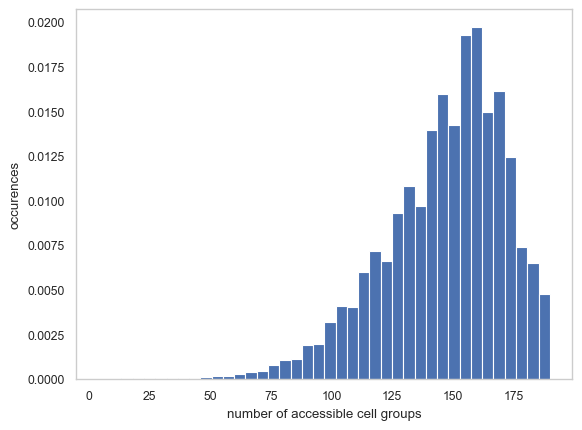

In [32]:
adata_peaks_ct_tp.obs["n_cells_by_counts"].hist(bins=40, density=True)
plt.xlabel("number of accessible cell groups")
plt.ylabel("occurences")
plt.grid(False)
plt.savefig(figpath+"hist_num_accessible_groups_all.pdf")
plt.show()

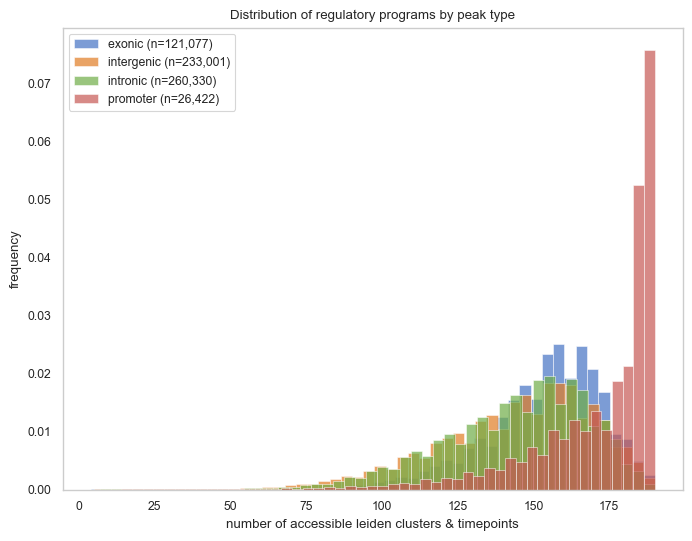

In [24]:
plt.figure(figsize=(8, 6))

# Your specified colors (updated)
color_map = {
    'exonic': '#4472C4',      # blue
    'intergenic': '#E07C24',  # orange  
    'intronic': '#70AD47',    # green
    'promoter': '#C65854'     # red
}

for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type_argelaguet'] == peak_type]
    plt.hist(subset['n_cells_by_counts'], bins=50, alpha=0.7, density=True,
             label=f'{peak_type} (n={len(subset):,})', 
             color=color_map[peak_type], edgecolor='white', linewidth=0.5)

plt.xlabel('number of accessible leiden clusters & timepoints')
plt.ylabel('frequency')
plt.legend()
# plt.yscale("log")
plt.title('Distribution of regulatory programs by peak type')
plt.grid(False)
plt.savefig(figpath + "hist_num_accessible_groups_by_peak_type_argelaguet.pdf")
plt.show()

### Let's see if the promoter region is more accessible than the rest peak types (for celltype and timepoints)

In [13]:
# # Parse the cell type and timepoint from the var index
# var_info = []
# for idx in adata_peaks.var.index:
#     parts = idx.rsplit('_', 1)  # Split on LAST underscore only
#     cell_type = parts[0]
#     timepoint = parts[1]
#     var_info.append({'sample_id': idx, 'cell_type': cell_type, 'timepoint': timepoint})

# var_df = pd.DataFrame(var_info)
# print("Sample of parsed identifiers:")
# print(var_df.head(10))

# # Get the count matrix (peaks x samples)
# # X = adata_peaks.layers["sum"]
# X = adata_peaks.X.copy()
# if hasattr(X, 'toarray'):  # If it's a sparse matrix
#     X = X.toarray()

# # For TIMEPOINTS: collapse across cell types
# # For each timepoint, check if peak is accessible in ANY cell type at that timepoint
# timepoint_accessibility = {}
# for timepoint in var_df['timepoint'].unique():
#     # Get all sample indices for this timepoint (across all cell types)
#     sample_indices = var_df[var_df['timepoint'] == timepoint].index.tolist()
#     # For each peak, check if it's accessible in ANY sample from this timepoint
#     timepoint_accessibility[timepoint] = (X[:, sample_indices] > 0).any(axis=1).astype(int)

# timepoint_df = pd.DataFrame(timepoint_accessibility, index=adata_peaks_ct_tp.obs.index)
# print(f"\nTimepoint accessibility matrix shape: {timepoint_df.shape}")
# print("Sample of timepoint accessibility (0/1 for each timepoint):")
# print(timepoint_df.head())

# # For CELL TYPES: collapse across timepoints  
# # For each cell type, check if peak is accessible in ANY timepoint for that cell type
# celltype_accessibility = {}
# for cell_type in var_df['cell_type'].unique():
#     # Get all sample indices for this cell type (across all timepoints)
#     sample_indices = var_df[var_df['cell_type'] == cell_type].index.tolist()
#     # For each peak, check if it's accessible in ANY sample from this cell type
#     celltype_accessibility[cell_type] = (X[:, sample_indices] > 0).any(axis=1).astype(int)

# celltype_df = pd.DataFrame(celltype_accessibility, index=adata_peaks_ct_tp.obs.index)
# print(f"\nCell type accessibility matrix shape: {celltype_df.shape}")
# print("Sample of cell type accessibility (0/1 for each cell type):")
# print(celltype_df.head())

# # Sum to get total number of timepoints/cell types where each peak is accessible
# adata_peaks_ct_tp.obs['n_timepoints_accessible'] = timepoint_df.sum(axis=1)
# adata_peaks_ct_tp.obs['n_celltypes_accessible'] = celltype_df.sum(axis=1)

# print(f"\nSummary statistics:")
# print(f"Number of unique timepoints: {len(var_df['timepoint'].unique())}")
# print(f"Number of unique cell types: {len(var_df['cell_type'].unique())}")
# print(f"Timepoints accessible per peak - mean: {adata_peaks_ct_tp.obs['n_timepoints_accessible'].mean():.2f}, max: {adata_peaks_ct_tp.obs['n_timepoints_accessible'].max()}")
# print(f"Cell types accessible per peak - mean: {adata_peaks_ct_tp.obs['n_celltypes_accessible'].mean():.2f}, max: {adata_peaks_ct_tp.obs['n_celltypes_accessible'].max()}")

# print(f"\nUnique timepoints: {sorted(var_df['timepoint'].unique(), key=lambda x: int(x.replace('somites', '')))}")
# print(f"Unique cell types: {sorted(var_df['cell_type'].unique())}")

Sample of parsed identifiers:
     sample_id cell_type  timepoint
0   0_0somites         0   0somites
1   0_5somites         0   5somites
2  0_10somites         0  10somites
3  0_15somites         0  15somites
4  0_20somites         0  20somites
5  0_30somites         0  30somites
6   1_0somites         1   0somites
7   1_5somites         1   5somites
8  1_10somites         1  10somites
9  1_15somites         1  15somites

Timepoint accessibility matrix shape: (640830, 6)
Sample of timepoint accessibility (0/1 for each timepoint):
             0somites  5somites  10somites  15somites  20somites  30somites
1-32-526            1         1          1          1          1          1
1-2372-3057         1         1          1          1          1          1
1-3427-4032         1         1          1          1          1          1
1-4469-7268         1         1          1          1          1          1
1-9541-9969         1         1          1          1          1          1

Cell t

In [14]:
# Parse the cell type and timepoint from the var index
var_info = []
for idx in adata_peaks_ct_tp.var.index:
    parts = idx.rsplit('_', 1)  # Split on LAST underscore only
    cell_type = parts[0]
    timepoint = parts[1]
    var_info.append({'sample_id': idx, 'cell_type': cell_type, 'timepoint': timepoint})

var_df = pd.DataFrame(var_info)
print("Sample of parsed identifiers:")
print(var_df.head(10))

# Get the count matrix (peaks x samples)
X = adata_peaks_ct_tp.layers["sum"]
if hasattr(X, 'toarray'):  # If it's a sparse matrix
    X = X.toarray()

# For TIMEPOINTS: collapse across cell types
# For each timepoint, check if peak is accessible in ANY cell type at that timepoint
timepoint_accessibility = {}
for timepoint in var_df['timepoint'].unique():
    # Get all sample indices for this timepoint (across all cell types)
    sample_indices = var_df[var_df['timepoint'] == timepoint].index.tolist()
    # For each peak, check if it's accessible in ANY sample from this timepoint
    timepoint_accessibility[timepoint] = (X[:, sample_indices] > 0).any(axis=1).astype(int)

timepoint_df = pd.DataFrame(timepoint_accessibility, index=adata_peaks_ct_tp.obs.index)
print(f"\nTimepoint accessibility matrix shape: {timepoint_df.shape}")
print("Sample of timepoint accessibility (0/1 for each timepoint):")
print(timepoint_df.head())

# For CELL TYPES: collapse across timepoints  
# For each cell type, check if peak is accessible in ANY timepoint for that cell type
celltype_accessibility = {}
for cell_type in var_df['cell_type'].unique():
    # Get all sample indices for this cell type (across all timepoints)
    sample_indices = var_df[var_df['cell_type'] == cell_type].index.tolist()
    # For each peak, check if it's accessible in ANY sample from this cell type
    celltype_accessibility[cell_type] = (X[:, sample_indices] > 0).any(axis=1).astype(int)

celltype_df = pd.DataFrame(celltype_accessibility, index=adata_peaks_ct_tp.obs.index)
print(f"\nCell type accessibility matrix shape: {celltype_df.shape}")
print("Sample of cell type accessibility (0/1 for each cell type):")
print(celltype_df.head())

# Sum to get total number of timepoints/cell types where each peak is accessible
adata_peaks_ct_tp.obs['n_timepoints_accessible'] = timepoint_df.sum(axis=1)
adata_peaks_ct_tp.obs['n_celltypes_accessible'] = celltype_df.sum(axis=1)

print(f"\nSummary statistics:")
print(f"Number of unique timepoints: {len(var_df['timepoint'].unique())}")
print(f"Number of unique cell types: {len(var_df['cell_type'].unique())}")
print(f"Timepoints accessible per peak - mean: {adata_peaks_ct_tp.obs['n_timepoints_accessible'].mean():.2f}, max: {adata_peaks_ct_tp.obs['n_timepoints_accessible'].max()}")
print(f"Cell types accessible per peak - mean: {adata_peaks_ct_tp.obs['n_celltypes_accessible'].mean():.2f}, max: {adata_peaks_ct_tp.obs['n_celltypes_accessible'].max()}")

print(f"\nUnique timepoints: {sorted(var_df['timepoint'].unique(), key=lambda x: int(x.replace('somites', '')))}")
print(f"Unique cell types: {sorted(var_df['cell_type'].unique())}")

Sample of parsed identifiers:
        sample_id cell_type  timepoint
0   NMPs_0somites      NMPs   0somites
1   NMPs_5somites      NMPs   5somites
2  NMPs_10somites      NMPs  10somites
3  NMPs_15somites      NMPs  15somites
4  NMPs_20somites      NMPs  20somites
5  NMPs_30somites      NMPs  30somites
6    PSM_0somites       PSM   0somites
7    PSM_5somites       PSM   5somites
8   PSM_10somites       PSM  10somites
9   PSM_15somites       PSM  15somites

Timepoint accessibility matrix shape: (640830, 6)
Sample of timepoint accessibility (0/1 for each timepoint):
             0somites  5somites  10somites  15somites  20somites  30somites
1-32-526            1         1          1          1          1          1
1-2372-3057         1         1          1          1          1          1
1-3427-4032         1         1          1          1          1          1
1-4469-7268         1         1          1          1          1          1
1-9541-9969         1         1          1        

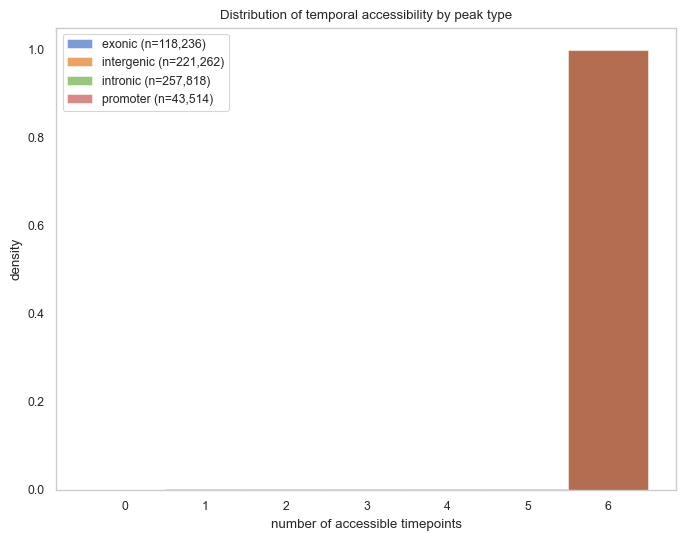

In [15]:
plt.figure(figsize=(8, 6))
color_map = {
    'exonic': '#4472C4',      # blue
    'intergenic': '#E07C24',  # orange  
    'intronic': '#70AD47',    # green
    'promoter': '#C65854'     # red
}

max_timepoints = adata_peaks_ct_tp.obs['n_timepoints_accessible'].max()
# Create bins centered on integers: bin edges at -0.5, 0.5, 1.5, etc.
bins = np.arange(-0.5, max_timepoints + 1.5, 1)

for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type'] == peak_type]
    plt.hist(subset['n_timepoints_accessible'], bins=bins, alpha=0.7, density=True,
             label=f'{peak_type} (n={len(subset):,})', 
             color=color_map[peak_type], edgecolor='white', linewidth=0.5)

plt.xlabel('number of accessible timepoints')
plt.ylabel('density')
plt.legend()
plt.title('Distribution of temporal accessibility by peak type')
plt.xticks(range(max_timepoints + 1))  # Integer tick marks
plt.grid(False)
plt.savefig(figpath + "hist_discrete_accessible_timepoints_by_peak_type.pdf")
plt.show()

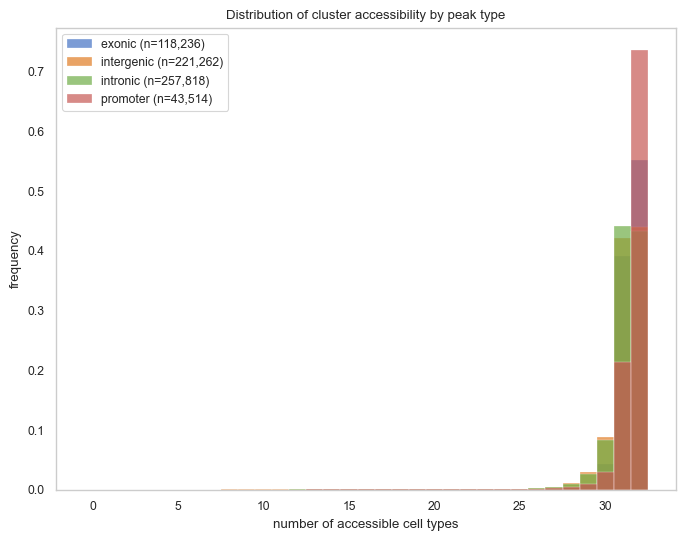

In [16]:
plt.figure(figsize=(8, 6))
# Your specified colors (updated)
color_map = {
    'exonic': '#4472C4',      # blue
    'intergenic': '#E07C24',  # orange  
    'intronic': '#70AD47',    # green
    'promoter': '#C65854'     # red
}

# Get the range of values to create proper bins
max_celltypes = adata_peaks_ct_tp.obs['n_celltypes_accessible'].max()
# Create bins with no gaps: bin edges at -0.5, 0.5, 1.5, etc.
bins = np.arange(-0.5, max_celltypes + 1.5, 1)

for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type'] == peak_type]
    plt.hist(subset['n_celltypes_accessible'], bins=bins, alpha=0.7, density=True,
             label=f'{peak_type} (n={len(subset):,})', 
             color=color_map[peak_type], edgecolor='white', linewidth=0.3)
plt.xlabel('number of accessible cell types')
plt.ylabel('frequency')
plt.legend()
# plt.yscale("log")
plt.title('Distribution of cluster accessibility by peak type')
plt.grid(False)
# plt.savefig(figpath + "hist_num_accessible_celltypes_by_peak_type.pdf")
plt.show()

### NOTE THAT these were "binarized" accessibility, so this could be over-estimated (As there should be groups with minimal accessibility close to "noise"

## Step 2. Chromatin accessibility (thresholded by their magnitude) distribution

### Threshold the chromatin accessibility as high, medium, and low

In [17]:
from skimage.filters import threshold_otsu
from sklearn.mixture import GaussianMixture

In [18]:
# First, let's look at the distribution of chr.accessibility profiles (aggregated over time, or celltype)

# Get the count matrix and parse sample info (from your earlier code)
X = adata_peaks_ct_tp.X
if hasattr(X, 'toarray'):
    X = X.toarray()

# Parse sample information
var_info = []
for i, idx in enumerate(adata_peaks_ct_tp.var.index):
    parts = idx.rsplit('_', 1)
    cell_type = parts[0]
    timepoint = parts[1]
    var_info.append({
        'sample_idx': i,
        'sample_id': idx, 
        'cell_type': cell_type, 
        'timepoint': timepoint
    })

var_df = pd.DataFrame(var_info)
print(f"Parsed {len(var_df)} samples: {len(var_df['cell_type'].unique())} cell types, {len(var_df['timepoint'].unique())} timepoints")

Parsed 190 samples: 32 cell types, 6 timepoints


In [19]:
# a function to aggregate the counts using metadata
# 1. AGGREGATE BY CELL TYPE (sum across timepoints)
print("\n📊 AGGREGATING BY CELL TYPE...")
celltype_aggregated = {}
for cell_type in var_df['cell_type'].unique():
    sample_indices = var_df[var_df['cell_type'] == cell_type]['sample_idx'].tolist()
    celltype_aggregated[cell_type] = X[:, sample_indices].sum(axis=1)

celltype_agg_df = pd.DataFrame(celltype_aggregated, index=adata_peaks_ct_tp.obs.index)
celltype_agg_df = celltype_agg_df.reindex(sorted(celltype_agg_df.columns), axis=1)

print(f"Cell type aggregated matrix shape: {celltype_agg_df.shape}")
print("Sample aggregated accessibility by cell type:")
print(celltype_agg_df.describe().round(2))


📊 AGGREGATING BY CELL TYPE...
Cell type aggregated matrix shape: (640830, 32)
Sample aggregated accessibility by cell type:
            NMPs        PSM  differentiating_neurons  endocrine_pancreas  \
count  640830.00  640830.00                640830.00           640830.00   
mean       62.94     147.88                    63.09               96.73   
std       193.84     463.48                   175.12              271.59   
min         0.00       0.00                     0.00                0.00   
25%         9.00      21.00                     9.00               15.00   
50%        18.00      40.00                    18.00               28.00   
75%        39.00      87.00                    41.00               63.00   
max      8540.00   19526.00                  7499.00            12321.00   

        endoderm  enteric_neurons  epidermis  fast_muscle  floor_plate  \
count  640830.00        640830.00  640830.00    640830.00    640830.00   
mean       61.79            23.68     290.

In [20]:
# 2. AGGREGATE BY TIMEPOINT (sum across cell types)
print("\n📊 AGGREGATING BY TIMEPOINT...")
timepoint_aggregated = {}
for timepoint in var_df['timepoint'].unique():
    sample_indices = var_df[var_df['timepoint'] == timepoint]['sample_idx'].tolist()
    timepoint_aggregated[timepoint] = X[:, sample_indices].sum(axis=1)

timepoint_agg_df = pd.DataFrame(timepoint_aggregated, index=adata_peaks_ct_tp.obs.index)
timepoint_order = sorted(timepoint_agg_df.columns, key=lambda x: int(x.replace('somites', '')))
timepoint_agg_df = timepoint_agg_df.reindex(timepoint_order, axis=1)

print(f"Timepoint aggregated matrix shape: {timepoint_agg_df.shape}")
print("Sample aggregated accessibility by timepoint:")
print(timepoint_agg_df.describe().round(2))


📊 AGGREGATING BY TIMEPOINT...
Timepoint aggregated matrix shape: (640830, 6)
Sample aggregated accessibility by timepoint:
        0somites   5somites  10somites  15somites  20somites  30somites
count  640830.00  640830.00  640830.00  640830.00  640830.00  640830.00
mean      513.77     630.13     385.51     587.01     702.77     109.90
std      1527.82    1768.16    1073.87    1670.52    2024.23     363.46
min         0.00       0.00       0.00       0.00       0.00       0.00
25%        76.00     107.00      59.00      92.00     104.00      19.00
50%       146.00     202.00     115.00     174.00     199.00      34.00
75%       320.00     425.00     256.00     379.00     442.00      66.00
max     69839.00   82609.00   45362.00   71263.00   79627.00   17646.00


In [21]:
# First, let's look at the distribution
# (1) peaks-by-celltypes (summed over time)
# (2) peaks-by-timepoints (summed over celltypes)

# Create the peaks-by-celltypes matrix (already done, but let's be explicit)
celltype_agg_df = pd.DataFrame(celltype_aggregated, index=adata_peaks_ct_tp.obs.index)
celltype_agg_df = celltype_agg_df.reindex(sorted(celltype_agg_df.columns), axis=1)

print(f"Matrix shape: {celltype_agg_df.shape} (peaks × cell types)")
print(f"Cell types: {list(celltype_agg_df.columns)}")

Matrix shape: (640830, 32) (peaks × cell types)
Cell types: ['NMPs', 'PSM', 'differentiating_neurons', 'endocrine_pancreas', 'endoderm', 'enteric_neurons', 'epidermis', 'fast_muscle', 'floor_plate', 'hatching_gland', 'heart_myocardium', 'hemangioblasts', 'hematopoietic_vasculature', 'hindbrain', 'lateral_plate_mesoderm', 'midbrain_hindbrain_boundary', 'muscle', 'neural', 'neural_crest', 'neural_floor_plate', 'neural_optic', 'neural_posterior', 'neural_telencephalon', 'neurons', 'notochord', 'optic_cup', 'pharyngeal_arches', 'primordial_germ_cells', 'pronephros', 'somites', 'spinal_cord', 'tail_bud']


In [22]:
# Analyze the overall distribution across all cell types
print("\n📊 OVERALL ACCESSIBILITY DISTRIBUTION ANALYSIS")
print("-" * 50)

# Flatten all values to see overall distribution
all_values = celltype_agg_df.values.flatten()
non_zero_values = all_values[all_values > 0]

print(f"Total observations: {len(all_values):,}")
print(f"Non-zero observations: {len(non_zero_values):,} ({len(non_zero_values)/len(all_values)*100:.1f}%)")
print(f"Zero observations: {len(all_values) - len(non_zero_values):,}")

# Basic statistics
print(f"\nOverall statistics (non-zero values):")
print(f"  Mean: {non_zero_values.mean():.2f}")
print(f"  Median: {np.median(non_zero_values):.2f}")
print(f"  95th percentile: {np.percentile(non_zero_values, 95):.2f}")
print(f"  99th percentile: {np.percentile(non_zero_values, 99):.2f}")

# Apply Otsu to overall distribution
if len(non_zero_values) > 100:
    overall_otsu_threshold = threshold_otsu(non_zero_values)
    high_signal_count = (non_zero_values > overall_otsu_threshold).sum()
    print(f"\nOverall Otsu threshold: {overall_otsu_threshold:.2f}")
    print(f"Values above Otsu: {high_signal_count:,} ({high_signal_count/len(non_zero_values)*100:.1f}%)")



📊 OVERALL ACCESSIBILITY DISTRIBUTION ANALYSIS
--------------------------------------------------
Total observations: 20,506,560
Non-zero observations: 20,047,667 (97.8%)
Zero observations: 458,893

Overall statistics (non-zero values):
  Mean: 93.63
  Median: 23.00
  95th percentile: 342.00
  99th percentile: 1489.00

Overall Otsu threshold: 1296.19
Values above Otsu: 243,915 (1.2%)


In [24]:
print("📊 SIMPLE ACCESSIBILITY DISTRIBUTION ANALYSIS")
print("="*60)

# We already have celltype_agg_df and timepoint_agg_df from before
# Let's create total accessibility for each peak by summing across cell types/timepoints

# 1. Total accessibility per peak (sum across all cell types)
total_celltype_accessibility = celltype_agg_df.sum(axis=1)
adata_peaks_ct_tp.obs['total_celltype_accessibility'] = total_celltype_accessibility

# 2. Total accessibility per peak (sum across all timepoints)  
total_timepoint_accessibility = timepoint_agg_df.sum(axis=1)
adata_peaks_ct_tp.obs['total_timepoint_accessibility'] = total_timepoint_accessibility

print(f"Cell type aggregated accessibility - Mean: {total_celltype_accessibility.mean():.2f}, Max: {total_celltype_accessibility.max():.2f}")
print(f"Timepoint aggregated accessibility - Mean: {total_timepoint_accessibility.mean():.2f}, Max: {total_timepoint_accessibility.max():.2f}")


📊 SIMPLE ACCESSIBILITY DISTRIBUTION ANALYSIS
Cell type aggregated accessibility - Mean: 2929.08, Max: 364844.00
Timepoint aggregated accessibility - Mean: 2929.08, Max: 364844.00


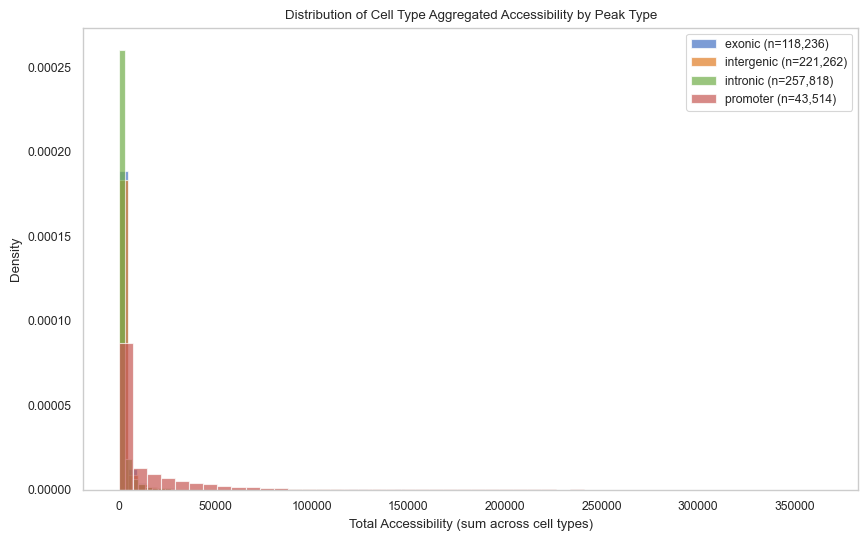

In [25]:
# Your color scheme
color_map = {
    'exonic': '#4472C4',      # blue
    'intergenic': '#E07C24',  # orange  
    'intronic': '#70AD47',    # green
    'promoter': '#C65854'     # red
}

# Plot 1: Cell type aggregated accessibility
plt.figure(figsize=(10, 6))
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type'] == peak_type]
    plt.hist(subset['total_celltype_accessibility'], bins=50, alpha=0.7, density=True,
             label=f'{peak_type} (n={len(subset):,})', 
             color=color_map[peak_type], edgecolor=None, rwidth=1.0)

plt.xlabel('Total Accessibility (sum across cell types)')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of Cell Type Aggregated Accessibility by Peak Type')
# plt.yscale('log')  # Log scale to see the distributions better
plt.grid(False)
# plt.grid(True, alpha=0.3)
# plt.savefig(figpath + "simple_celltype_accessibility_by_peak_type.pdf")
plt.show()

In [26]:
adata_peaks_ct_tp.obs["total_celltype_accessibility"].sort_values(ascending=False)

10-73855-77448          364844.0
17-53383392-53383848    250423.0
14-31564921-31567544    244907.0
7-33683082-33686500     239349.0
7-21721058-21724007     238292.0
                          ...   
3-3103555-3103821           12.0
16-52064766-52065031        11.0
1-58287472-58287674         10.0
4-59848534-59848733          8.0
7-2736417-2736621            5.0
Name: total_celltype_accessibility, Length: 640830, dtype: float64

In [69]:
def apply_otsu_analysis(data_df, analysis_type="Unknown"):
    """Apply Otsu's method to each column of aggregated data"""
    print(f"\n🔍 OTSU'S METHOD ANALYSIS: {analysis_type}")
    print("-" * 50)
    
    otsu_results = {}
    
    for column in data_df.columns:
        values = data_df[column].values
        
        # Remove zeros for cleaner threshold detection
        non_zero_values = values[values > 0]
        
        if len(non_zero_values) < 100:  # Need sufficient data points
            print(f"⚠️  {column}: Too few non-zero values ({len(non_zero_values)}), skipping")
            continue
            
        # Apply Otsu's method
        otsu_threshold = threshold_otsu(non_zero_values)
        
        # Calculate categories based on Otsu threshold
        low_count = (values <= otsu_threshold).sum()
        high_count = (values > otsu_threshold).sum()
        zero_count = (values == 0).sum()
        
        # Calculate some statistics
        mean_low = values[values <= otsu_threshold].mean() if low_count > 0 else 0
        mean_high = values[values > otsu_threshold].mean() if high_count > 0 else 0
        
        otsu_results[column] = {
            'threshold': otsu_threshold,
            'n_low': low_count,
            'n_high': high_count,
            'n_zero': zero_count,
            'mean_low': mean_low,
            'mean_high': mean_high,
            'pct_high': (high_count / len(values)) * 100,
            'fold_change': mean_high / mean_low if mean_low > 0 else np.inf
        }
        
        print(f"{column:20}: threshold={otsu_threshold:8.2f}, high={high_count:6,} ({high_count/len(values)*100:5.1f}%), fold_change={mean_high/mean_low if mean_low > 0 else float('inf'):6.2f}")
    
    return otsu_results

# Apply Otsu to cell type aggregated data
celltype_otsu = apply_otsu_analysis(celltype_agg_df, "CELL TYPE AGGREGATED")

# Apply Otsu to timepoint aggregated data  
timepoint_otsu = apply_otsu_analysis(timepoint_agg_df, "TIMEPOINT AGGREGATED")


🔍 OTSU'S METHOD ANALYSIS: CELL TYPE AGGREGATED
--------------------------------------------------
NMPs                : threshold=  634.00, high=12,634 (  2.0%), fold_change= 29.48
PSM                 : threshold=  620.67, high=13,362 (  2.1%), fold_change= 29.53
differentiating_neurons: threshold=  513.53, high=16,166 (  2.5%), fold_change= 24.19
endocrine_pancreas  : threshold=  548.11, high=14,649 (  2.3%), fold_change= 24.99
endoderm            : threshold=  514.31, high=15,617 (  2.4%), fold_change= 23.71
enteric_neurons     : threshold=  476.32, high=16,163 (  2.5%), fold_change= 20.90
epidermis           : threshold=  538.78, high=15,324 (  2.4%), fold_change= 24.72
fast_muscle         : threshold=  544.14, high=15,162 (  2.4%), fold_change= 25.36
floor_plate         : threshold=  664.14, high=12,665 (  2.0%), fold_change= 31.48
hatching_gland      : threshold=  552.54, high=14,379 (  2.2%), fold_change= 25.58
heart_myocardium    : threshold=  556.95, high=14,361 (  2.2%), fold

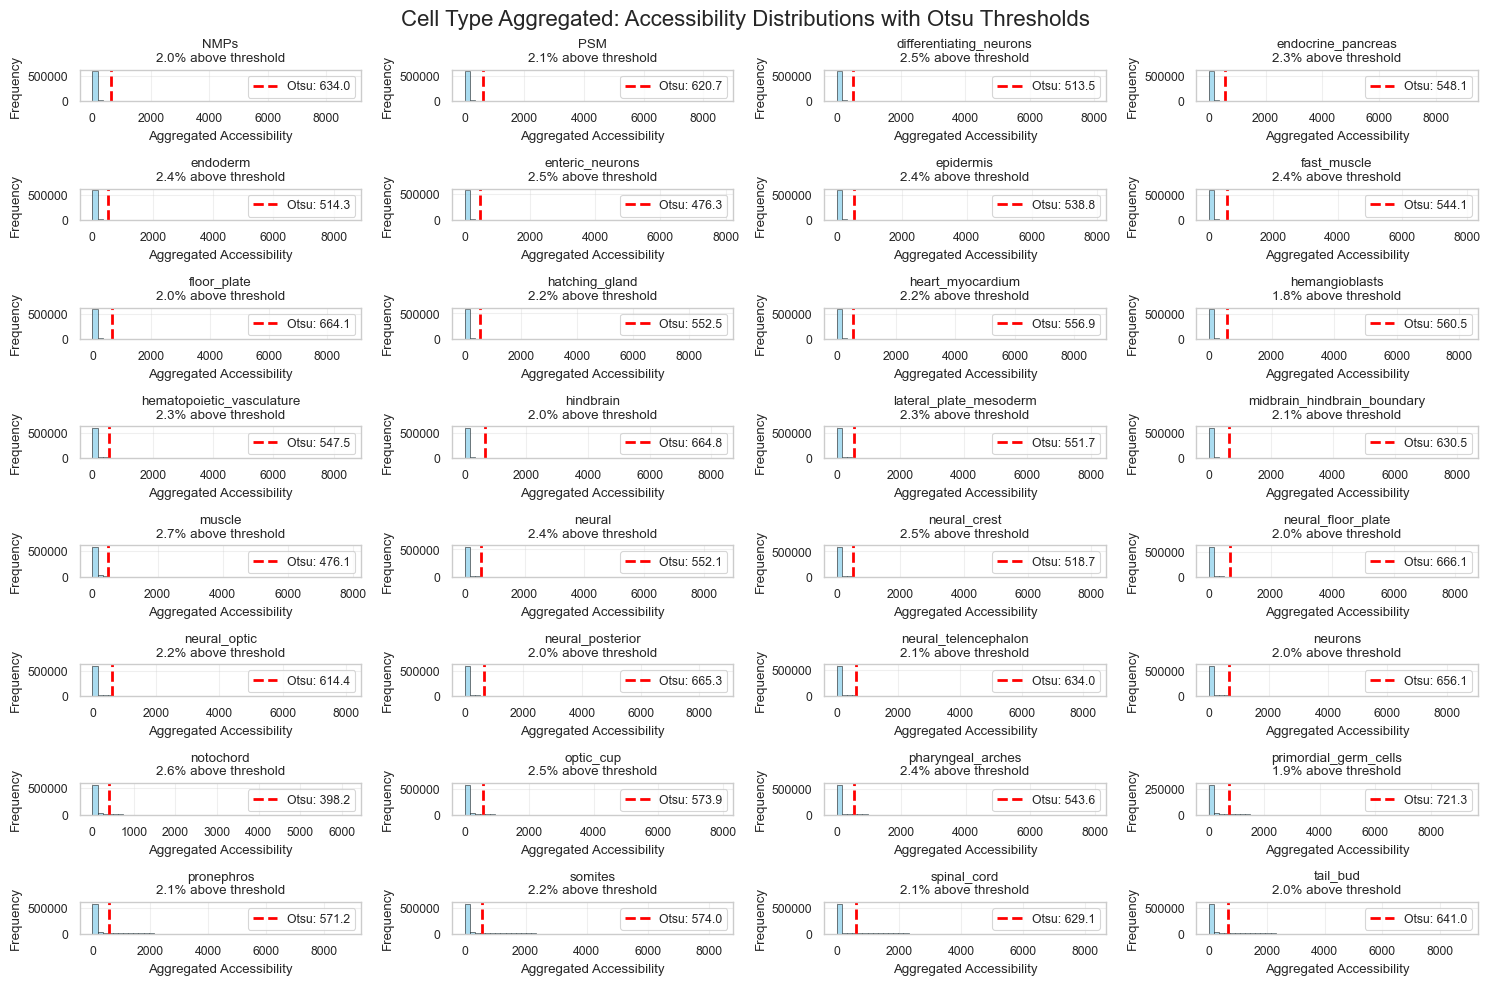

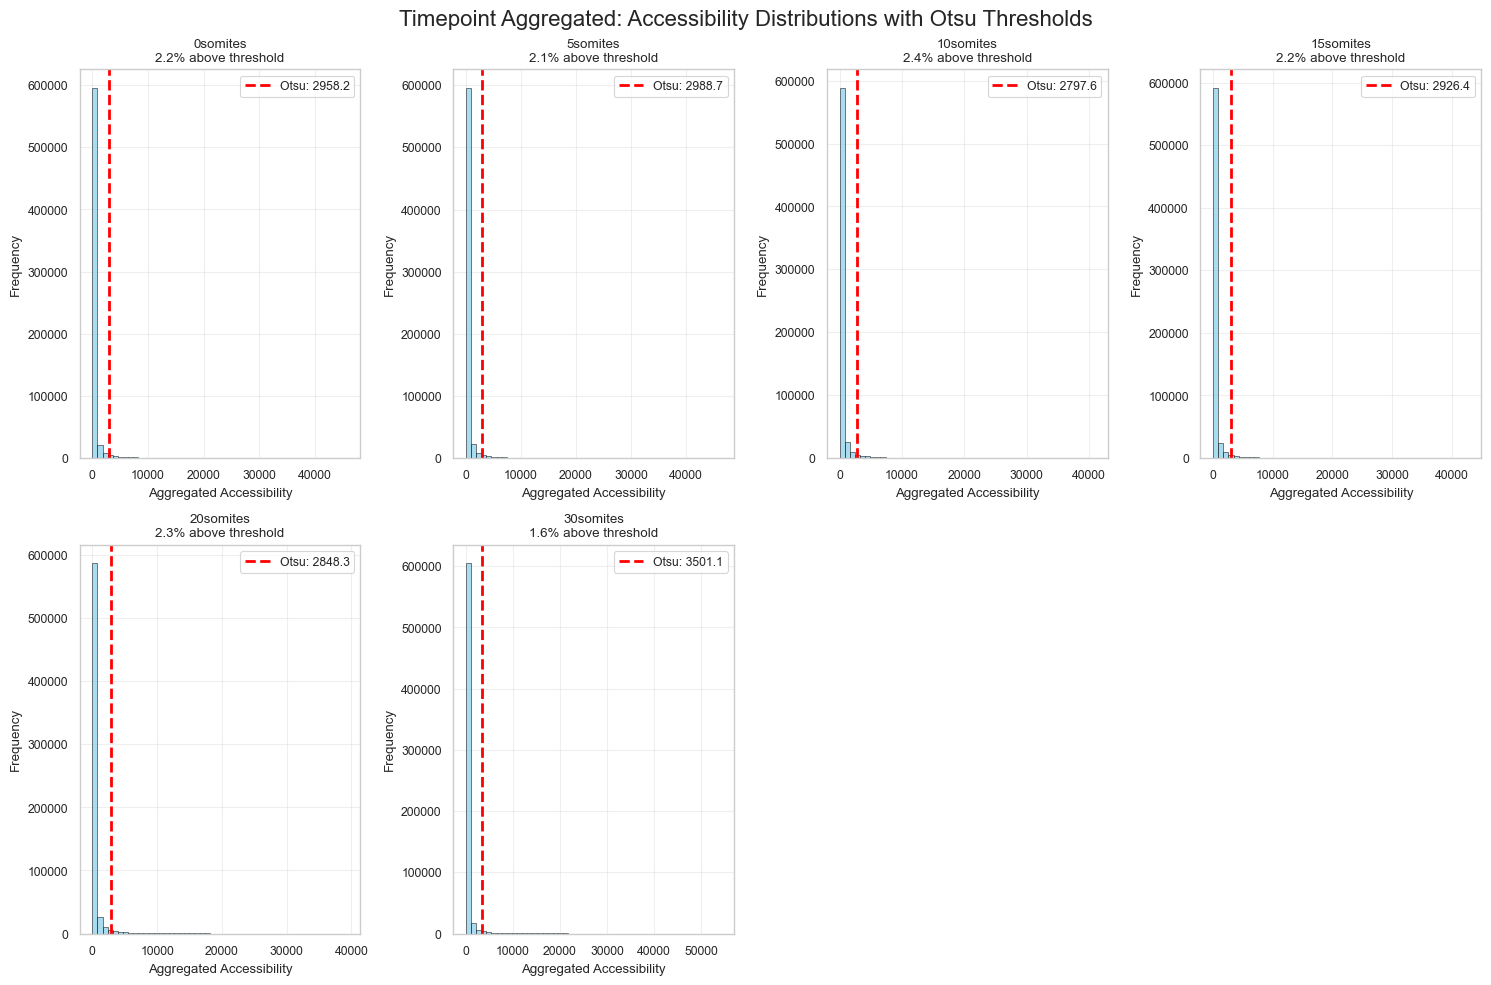

In [70]:
def plot_otsu_distributions(data_df, otsu_results, title_prefix, figsize=(15, 10)):
    """Plot distributions with Otsu thresholds"""
    
    n_cols = min(4, len(data_df.columns))
    n_rows = (len(data_df.columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    axes = axes.flatten()
    
    for i, column in enumerate(data_df.columns):
        if i >= len(axes):
            break
            
        values = data_df[column].values
        non_zero_values = values[values > 0]
        
        if column in otsu_results:
            threshold = otsu_results[column]['threshold']
            
            # Plot histogram
            axes[i].hist(non_zero_values, bins=50, alpha=0.7, color='skyblue', 
                        edgecolor='black', linewidth=0.5)
            
            # Add Otsu threshold line
            axes[i].axvline(threshold, color='red', linestyle='--', linewidth=2, 
                           label=f'Otsu: {threshold:.1f}')
            
            # Add statistics
            pct_high = otsu_results[column]['pct_high']
            axes[i].set_title(f'{column}\n{pct_high:.1f}% above threshold')
            axes[i].legend()
        else:
            axes[i].hist(non_zero_values, bins=50, alpha=0.7, color='lightgray')
            axes[i].set_title(f'{column}\n(insufficient data)')
            
        axes[i].set_xlabel('Aggregated Accessibility')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(len(data_df.columns), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'{title_prefix}: Accessibility Distributions with Otsu Thresholds', 
                fontsize=16, y=0.98)
    plt.tight_layout()
    return fig

# Plot cell type distributions
fig1 = plot_otsu_distributions(celltype_agg_df, celltype_otsu, "Cell Type Aggregated")
plt.savefig(figpath + "otsu_celltype_distributions.pdf", bbox_inches='tight')
plt.show()

# Plot timepoint distributions  
fig2 = plot_otsu_distributions(timepoint_agg_df, timepoint_otsu, "Timepoint Aggregated")
plt.savefig(figpath + "otsu_timepoint_distributions.pdf", bbox_inches='tight')
plt.show()

In [86]:
print("🏷️  ANNOTATING PEAKS USING OTSU THRESHOLDS")
print("="*60)

# Function to apply Otsu and create annotations
def create_otsu_annotations(aggregated_df, annotation_prefix):
    """
    Apply Otsu thresholds and create binary annotations for each condition
    """
    otsu_thresholds = {}
    annotations = {}
    
    for condition in aggregated_df.columns:
        values = aggregated_df[condition].values
        non_zero_values = values[values > 0]
        
        if len(non_zero_values) > 100:  # Need sufficient data
            # Calculate Otsu threshold
            otsu_thresh = threshold_otsu(non_zero_values)
            otsu_thresholds[condition] = otsu_thresh
            
            # Create binary annotation: 1 = highly accessible, 0 = low accessibility
            high_accessibility = (values > otsu_thresh).astype(int)
            annotations[f'{annotation_prefix}_{condition}_high'] = high_accessibility
            
            # Also store the actual values for reference
            annotations[f'{annotation_prefix}_{condition}_value'] = values
            
            # Count peaks above threshold
            n_high = high_accessibility.sum()
            pct_high = (n_high / len(values)) * 100
            
            print(f"{condition:25}: threshold={otsu_thresh:6.1f}, high_peaks={n_high:5,} ({pct_high:4.1f}%)")
    
    return annotations, otsu_thresholds

# Apply to both cell type and timepoint aggregated data
print("\n📊 CELL TYPE ANNOTATIONS:")
print("-" * 40)
celltype_annotations, celltype_thresholds = create_otsu_annotations(celltype_agg_df, 'celltype')

print(f"\n📊 TIMEPOINT ANNOTATIONS:")
print("-" * 40)
timepoint_annotations, timepoint_thresholds = create_otsu_annotations(timepoint_agg_df, 'timepoint')


🏷️  ANNOTATING PEAKS USING OTSU THRESHOLDS

📊 CELL TYPE ANNOTATIONS:
----------------------------------------
NMPs                     : threshold= 634.0, high_peaks=12,634 ( 2.0%)
PSM                      : threshold= 620.7, high_peaks=13,362 ( 2.1%)
differentiating_neurons  : threshold= 513.5, high_peaks=16,166 ( 2.5%)
endocrine_pancreas       : threshold= 548.1, high_peaks=14,649 ( 2.3%)
endoderm                 : threshold= 514.3, high_peaks=15,617 ( 2.4%)
enteric_neurons          : threshold= 476.3, high_peaks=16,163 ( 2.5%)
epidermis                : threshold= 538.8, high_peaks=15,324 ( 2.4%)
fast_muscle              : threshold= 544.1, high_peaks=15,162 ( 2.4%)
floor_plate              : threshold= 664.1, high_peaks=12,665 ( 2.0%)
hatching_gland           : threshold= 552.5, high_peaks=14,379 ( 2.2%)
heart_myocardium         : threshold= 556.9, high_peaks=14,361 ( 2.2%)
hemangioblasts           : threshold= 560.5, high_peaks=11,586 ( 1.8%)
hematopoietic_vasculature: threshold= 

In [90]:
# Add all annotations to your adata object
print(f"\n✅ Adding annotations to adata_peaks_ct_tp.obs...")
for key, values in celltype_annotations.items():
    adata_peaks_ct_tp.obs[key] = values

for key, values in timepoint_annotations.items():
    adata_peaks_ct_tp.obs[key] = values

print(f"Added {len(celltype_annotations) + len(timepoint_annotations)} new annotation columns")


✅ Adding annotations to adata_peaks_ct_tp.obs...
Added 76 new annotation columns


In [91]:
# Create summary annotations: how many conditions is each peak highly accessible in?

print(f"\n📈 CREATING SUMMARY ANNOTATIONS:")
print("-" * 40)

# Count how many cell types each peak is highly accessible in
celltype_high_cols = [col for col in adata_peaks_ct_tp.obs.columns if col.startswith('celltype_') and col.endswith('_high')]
adata_peaks_ct_tp.obs['n_celltypes_high_otsu'] = adata_peaks_ct_tp.obs[celltype_high_cols].sum(axis=1)

# Count how many timepoints each peak is highly accessible in  
timepoint_high_cols = [col for col in adata_peaks_ct_tp.obs.columns if col.startswith('timepoint_') and col.endswith('_high')]
adata_peaks_ct_tp.obs['n_timepoints_high_otsu'] = adata_peaks_ct_tp.obs[timepoint_high_cols].sum(axis=1)

# Create categorical labels
def categorize_accessibility(n_conditions, total_conditions):
    if n_conditions == 0:
        return 'Not_Accessible'
    elif n_conditions == 1:
        return 'Specific'
    elif n_conditions <= total_conditions * 0.3:
        return 'Restricted'
    elif n_conditions <= total_conditions * 0.7:
        return 'Moderate'
    else:
        return 'Broad'

n_celltypes = len(celltype_high_cols)
n_timepoints = len(timepoint_high_cols)

adata_peaks_ct_tp.obs['celltype_accessibility_category'] = adata_peaks_ct_tp.obs['n_celltypes_high_otsu'].apply(
    lambda x: categorize_accessibility(x, n_celltypes))

adata_peaks_ct_tp.obs['timepoint_accessibility_category'] = adata_peaks_ct_tp.obs['n_timepoints_high_otsu'].apply(
    lambda x: categorize_accessibility(x, n_timepoints))

print(f"Cell type accessibility categories:")
print(adata_peaks_ct_tp.obs['celltype_accessibility_category'].value_counts())

print(f"\nTimepoint accessibility categories:")
print(adata_peaks_ct_tp.obs['timepoint_accessibility_category'].value_counts())


📈 CREATING SUMMARY ANNOTATIONS:
----------------------------------------
Cell type accessibility categories:
Not_Accessible    594296
Restricted         17290
Specific           13977
Broad               9420
Moderate            5847
Name: celltype_accessibility_category, dtype: int64

Timepoint accessibility categories:
Not_Accessible    622896
Broad              11840
Moderate            4208
Specific            1886
Name: timepoint_accessibility_category, dtype: int64


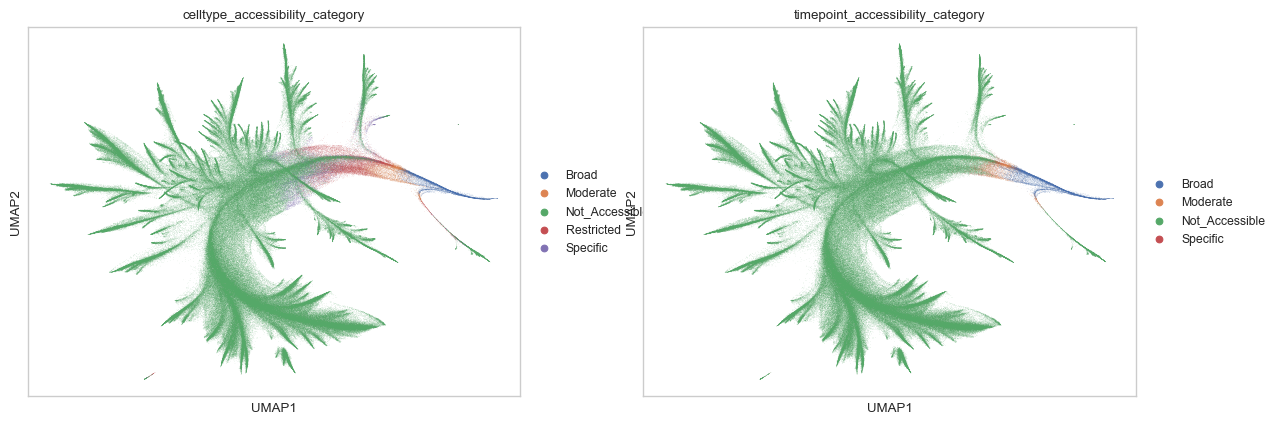

In [92]:
sc.pl.umap(adata_peaks_ct_tp, color=["celltype_accessibility_category", "timepoint_accessibility_category"])

### revisit with less harsh thresholds



In [93]:
def create_multilevel_annotations(aggregated_df, annotation_prefix="multilevel"):
    """Create 3-level accessibility annotations: Low, Medium, High"""
    
    print(f"\n📊 CREATING MULTI-LEVEL ANNOTATIONS:")
    print("-" * 50)
    
    annotations = {}
    
    for condition in aggregated_df.columns:
        values = aggregated_df[condition].values
        non_zero_values = values[values > 0]
        
        if len(non_zero_values) > 50:
            # Use 67th and 90th percentiles for 3-level classification
            low_threshold = np.percentile(non_zero_values, 67)   # Bottom 67% of non-zero
            high_threshold = np.percentile(non_zero_values, 90)  # Top 10% of non-zero
            
            # Create 3-level categories
            categories = np.where(values == 0, 'Zero',
                         np.where(values <= low_threshold, 'Low',
                         np.where(values <= high_threshold, 'Medium', 'High')))
            
            annotations[f'{annotation_prefix}_{condition}_level'] = categories
            
            # Count each category
            unique, counts = np.unique(categories, return_counts=True)
            count_dict = dict(zip(unique, counts))
            
            print(f"{condition:20}: Zero={count_dict.get('Zero', 0):5,} | "
                  f"Low={count_dict.get('Low', 0):5,} | "
                  f"Med={count_dict.get('Medium', 0):4,} | "
                  f"High={count_dict.get('High', 0):4,}")
    
    return annotations

# Apply multi-level classification
celltype_multilevel = create_multilevel_annotations(celltype_agg_df, "celltype_ml")
timepoint_multilevel = create_multilevel_annotations(timepoint_agg_df, "timepoint_ml")


📊 CREATING MULTI-LEVEL ANNOTATIONS:
--------------------------------------------------
NMPs                : Zero=2,177 | Low=427,897 | Med=146,890 | High=63,866
PSM                 : Zero=  263 | Low=429,180 | Med=147,330 | High=64,057
differentiating_neurons: Zero=2,287 | Low=427,825 | Med=146,863 | High=63,855
endocrine_pancreas  : Zero=  600 | Low=428,954 | Med=147,253 | High=64,023
endoderm            : Zero=2,025 | Low=427,999 | Med=146,925 | High=63,881
enteric_neurons     : Zero=19,179 | Low=416,509 | Med=142,977 | High=62,165
epidermis           : Zero=   50 | Low=429,322 | Med=147,380 | High=64,078
fast_muscle         : Zero=2,613 | Low=427,605 | Med=146,790 | High=63,822
floor_plate         : Zero=  606 | Low=428,950 | Med=147,251 | High=64,023
hatching_gland      : Zero=10,731 | Low=422,166 | Med=144,923 | High=63,010
heart_myocardium    : Zero=  624 | Low=428,938 | Med=147,247 | High=64,021
hemangioblasts      : Zero=8,706 | Low=423,554 | Med=145,357 | High=63,213
hematop

In [71]:
def create_accessibility_categories(data_df, otsu_results, category_name):
    """Create accessibility categories for each peak using Otsu thresholds"""
    
    categories = {}
    
    for column in data_df.columns:
        if column not in otsu_results:
            continue
            
        threshold = otsu_results[column]['threshold']
        values = data_df[column].values
        
        # Create categories: Low (≤ threshold), High (> threshold) 
        category_labels = np.where(values > threshold, 'High', 'Low')
        categories[f'{column}_{category_name}'] = category_labels
    
    # Add to your adata object
    for col_name, labels in categories.items():
        adata_peaks_ct_tp.obs[col_name] = labels
    
    return categories

# Create categories
celltype_categories = create_accessibility_categories(celltype_agg_df, celltype_otsu, "celltype_otsu")
timepoint_categories = create_accessibility_categories(timepoint_agg_df, timepoint_otsu, "timepoint_otsu")

print(f"\n✅ Created accessibility categories using Otsu thresholds")
print(f"Added {len(celltype_categories)} cell type categories and {len(timepoint_categories)} timepoint categories to adata_peaks_ct_tp.obs")


✅ Created accessibility categories using Otsu thresholds
Added 32 cell type categories and 6 timepoint categories to adata_peaks_ct_tp.obs


In [73]:
def analyze_categories_by_peak_type(category_dict, analysis_name):
    """Analyze how accessibility categories relate to peak types"""
    
    print(f"\n📈 CATEGORY ANALYSIS BY PEAK TYPE: {analysis_name}")
    print("=" * 60)
    
    # Example analysis using first category
    first_category = list(category_dict.keys())[0]
    
    for category_name in list(category_dict.keys())[:3]:  # Show first 3 as examples
        print(f"\n{category_name}:")
        crosstab = pd.crosstab(adata_peaks_ct_tp.obs['peak_type'], 
                              adata_peaks_ct_tp.obs[category_name])
        
        # Calculate percentages
        crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
        
        print("Counts:")
        print(crosstab)
        print("\nPercentages:")
        print(crosstab_pct.round(1))

# Analyze the categories
analyze_categories_by_peak_type(celltype_categories, "CELL TYPE OTSU")
analyze_categories_by_peak_type(timepoint_categories, "TIMEPOINT OTSU")

print(f"\n🎯 NEXT STEPS:")
print("1. Examine the Otsu thresholds - do they make biological sense?")
print("2. Look at the distributions - are they bimodal enough for Otsu?")
print("3. Check how categories relate to peak types - are promoters more accessible?")
print("4. If Otsu seems too simple, we can try Gaussian Mixture Models next!")


📈 CATEGORY ANALYSIS BY PEAK TYPE: CELL TYPE OTSU

NMPs_celltype_otsu:
Counts:
NMPs_celltype_otsu  High     Low
peak_type                       
exonic              1336  116900
intergenic          2084  219178
intronic            2099  255719
promoter            7115   36399

Percentages:
NMPs_celltype_otsu  High   Low
peak_type                     
exonic               1.1  98.9
intergenic           0.9  99.1
intronic             0.8  99.2
promoter            16.4  83.6

PSM_celltype_otsu:
Counts:
PSM_celltype_otsu  High     Low
peak_type                      
exonic             1424  116812
intergenic         2341  218921
intronic           2356  255462
promoter           7241   36273

Percentages:
PSM_celltype_otsu  High   Low
peak_type                    
exonic              1.2  98.8
intergenic          1.1  98.9
intronic            0.9  99.1
promoter           16.6  83.4

differentiating_neurons_celltype_otsu:
Counts:
differentiating_neurons_celltype_otsu  High     Low
peak_type

### REVISIT

In [117]:
from scipy import stats
from scipy.stats import mannwhitneyu, ks_2samp

def comprehensive_accessibility_analysis(adata, peak_type_col='peak_type', 
                                       total_conditions=192):
    """
    Comprehensive analysis of peak accessibility patterns
    
    Parameters:
    - adata: AnnData object with peak data
    - peak_type_col: column name containing peak type annotations
    - total_conditions: total number of celltype-timepoint combinations
    """
    
    # Get total accessibility counts (sum across all conditions)
    if hasattr(adata.X, 'toarray'):
        accessibility_matrix = adata.X.toarray()
    else:
        accessibility_matrix = adata.X
    
    total_accessibility = accessibility_matrix.sum(axis=1)
    
    # Get peak types
    peak_types = adata.obs[peak_type_col]
    
    # Calculate percentage accessibility
    pct_accessibility = (total_accessibility / total_conditions) * 100
    
    # Create comprehensive figure
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Distribution Comparison (Box plots)
    ax1 = plt.subplot(3, 3, 1)
    plot_data = pd.DataFrame({
        'peak_type': peak_types,
        'accessibility_count': total_accessibility
    })
    
    sns.boxplot(data=plot_data, x='peak_type', y='accessibility_count', ax=ax1)
    ax1.set_title('Accessibility Count Distribution by Peak Type')
    ax1.set_ylabel('Total Accessibility Count')
    plt.setp(ax1.get_xticklabels(), rotation=45)
    
    # 2. Violin plots for better distribution visualization
    ax2 = plt.subplot(3, 3, 2)
    sns.violinplot(data=plot_data, x='peak_type', y='accessibility_count', ax=ax2)
    ax2.set_title('Accessibility Distribution (Violin Plot)')
    ax2.set_ylabel('Total Accessibility Count')
    plt.setp(ax2.get_xticklabels(), rotation=45)
    
    # 3. Histogram overlays
    ax3 = plt.subplot(3, 3, 3)
    colors = {'exonic': '#5A9BD4', 'intergenic': '#FF7F0E', 'intronic': '#2CA02C', 'promoter': '#D62728'}
    color_list = ['#5A9BD4', '#FF7F0E', '#2CA02C', '#D62728']
    
    for i, peak_type in enumerate(['exonic', 'intergenic', 'intronic', 'promoter']):
        if peak_type in peak_types.unique():
            mask = peak_types == peak_type
            ax3.hist(total_accessibility[mask], alpha=0.6, bins=50, 
                    label=peak_type, color=colors[peak_type], density=True)
    
    ax3.set_xlabel('Total Accessibility Count')
    ax3.set_ylabel('Density')
    ax3.set_title('Accessibility Distribution Histograms')
    ax3.legend()
    
    # 4. Cumulative Distribution Functions
    ax4 = plt.subplot(3, 3, 4)
    for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
        if peak_type in peak_types.unique():
            mask = peak_types == peak_type
            values = np.sort(total_accessibility[mask])
            y = np.arange(1, len(values) + 1) / len(values)
            ax4.plot(values, y, label=peak_type, color=colors[peak_type], linewidth=2)
    
    ax4.set_xlabel('Total Accessibility Count')
    ax4.set_ylabel('Cumulative Probability')
    ax4.set_title('Cumulative Distribution Functions')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Accessibility threshold analysis
    ax5 = plt.subplot(3, 3, 5)
    thresholds = [0, 0.25, 0.5, 0.75, 0.9]
    threshold_labels = ['0-25%', '25-50%', '50-75%', '75-90%', '90-100%']
    
    threshold_data = []
    for peak_type in peak_types.unique():
        mask = peak_types == peak_type
        type_accessibility = pct_accessibility[mask]
        
        for i in range(len(thresholds)-1):
            lower = thresholds[i] * 100
            upper = thresholds[i+1] * 100
            count = ((type_accessibility >= lower) & (type_accessibility < upper)).sum()
            threshold_data.append({
                'peak_type': peak_type,
                'threshold_bin': threshold_labels[i],
                'count': count,
                'percentage': count / len(type_accessibility) * 100
            })
        
        # Handle the last bin (90-100%)
        count = (type_accessibility >= 90).sum()
        threshold_data.append({
            'peak_type': peak_type,
            'threshold_bin': '90-100%',
            'count': count,
            'percentage': count / len(type_accessibility) * 100
        })
    
    threshold_df = pd.DataFrame(threshold_data)
    
    # Pivot for stacked bar plot
    pivot_df = threshold_df.pivot(index='peak_type', columns='threshold_bin', values='percentage')
    pivot_df[threshold_labels + ['90-100%']].plot(kind='bar', stacked=True, ax=ax5)
    ax5.set_title('Peak Distribution by Accessibility Threshold')
    ax5.set_ylabel('Percentage of Peaks')
    ax5.set_xlabel('Peak Type')
    plt.setp(ax5.get_xticklabels(), rotation=45)
    
    # 6. Distance to TSS analysis
    ax6 = plt.subplot(3, 3, 6)
    distance_to_tss = np.abs(adata.obs['distance_to_tss'])
    
    scatter_data = pd.DataFrame({
        'distance': distance_to_tss,
        'accessibility': total_accessibility,
        'peak_type': peak_types
    })
    
    for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
        if peak_type in peak_types.unique():
            mask = peak_types == peak_type
            ax6.scatter(distance_to_tss[mask], total_accessibility[mask], 
                       alpha=0.6, s=1, label=peak_type, color=colors[peak_type])
    
    ax6.set_xlabel('Distance to TSS (bp)')
    ax6.set_ylabel('Total Accessibility Count')
    ax6.set_xscale('log')
    ax6.set_title('Accessibility vs Distance to TSS')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # 7. High accessibility percentage by peak type
    ax7 = plt.subplot(3, 3, 7)
    high_access_threshold = 0.8 * total_conditions  # 80% of max possible
    
    high_access_data = []
    for peak_type in peak_types.unique():
        mask = peak_types == peak_type
        type_accessibility = total_accessibility[mask]
        high_access_pct = (type_accessibility >= high_access_threshold).mean() * 100
        high_access_data.append({
            'peak_type': peak_type,
            'high_accessibility_pct': high_access_pct
        })
    
    high_access_df = pd.DataFrame(high_access_data)
    bars = ax7.bar(high_access_df['peak_type'], high_access_df['high_accessibility_pct'])
    ax7.set_title('Percentage of Peaks with High Accessibility (>80%)')
    ax7.set_ylabel('Percentage of Peaks')
    plt.setp(ax7.get_xticklabels(), rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 8. Statistical summary table (as text)
    ax8 = plt.subplot(3, 3, 8)
    ax8.axis('off')
    
    stats_text = "Statistical Summary:\n\n"
    for peak_type in peak_types.unique():
        mask = peak_types == peak_type
        type_accessibility = total_accessibility[mask]
        
        stats_text += f"{peak_type.upper()}:\n"
        stats_text += f"  N = {mask.sum()}\n"
        stats_text += f"  Mean: {type_accessibility.mean():.1f}\n"
        stats_text += f"  Median: {np.median(type_accessibility):.1f}\n"
        stats_text += f"  Std: {type_accessibility.std():.1f}\n"
        stats_text += f"  >80% accessible: {(type_accessibility >= high_access_threshold).mean()*100:.1f}%\n\n"
    
    ax8.text(0.05, 0.95, stats_text, transform=ax8.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace')
    
    # 9. Correlation matrix of peak types with accessibility
    ax9 = plt.subplot(3, 3, 9)
    
    # Create correlation data
    corr_data = pd.DataFrame({
        'distance_to_tss': np.log10(distance_to_tss + 1),  # log transform
        'accessibility': total_accessibility
    })
    
    # Add dummy variables for peak types
    for peak_type in peak_types.unique():
        corr_data[f'is_{peak_type}'] = (peak_types == peak_type).astype(int)
    
    correlation_matrix = corr_data.corr()
    
    # Plot correlation heatmap
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
                center=0, ax=ax9, fmt='.3f')
    ax9.set_title('Correlation Matrix')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical tests
    print("\nSTATISTICAL TESTS:")
    print("="*50)
    
    peak_type_list = list(peak_types.unique())
    
    # Mann-Whitney U tests between promoter and other types
    if 'promoter' in peak_type_list:
        promoter_mask = peak_types == 'promoter'
        promoter_accessibility = total_accessibility[promoter_mask]
        
        for other_type in peak_type_list:
            if other_type != 'promoter':
                other_mask = peak_types == other_type
                other_accessibility = total_accessibility[other_mask]
                
                # Mann-Whitney U test
                statistic, p_value = mannwhitneyu(promoter_accessibility, other_accessibility, 
                                                alternative='greater')
                
                # Effect size (Cohen's d)
                pooled_std = np.sqrt(((len(promoter_accessibility) - 1) * promoter_accessibility.var() + 
                                    (len(other_accessibility) - 1) * other_accessibility.var()) / 
                                   (len(promoter_accessibility) + len(other_accessibility) - 2))
                
                cohens_d = (promoter_accessibility.mean() - other_accessibility.mean()) / pooled_std
                
                print(f"\nPromoter vs {other_type}:")
                print(f"  Mann-Whitney U p-value: {p_value:.2e}")
                print(f"  Cohen's d (effect size): {cohens_d:.3f}")
                
                # Kolmogorov-Smirnov test
                ks_stat, ks_p = ks_2samp(promoter_accessibility, other_accessibility)
                print(f"  KS test p-value: {ks_p:.2e}")
    
    return plot_data, threshold_df, fig

# Usage:
# result_data, threshold_results = comprehensive_accessibility_analysis(
#     adata_peaks_ct_tp, 
#     peak_type_col='your_peak_type_column',  # adjust this
#     total_conditions=192  # 32 celltypes × 6 timepoints
# )

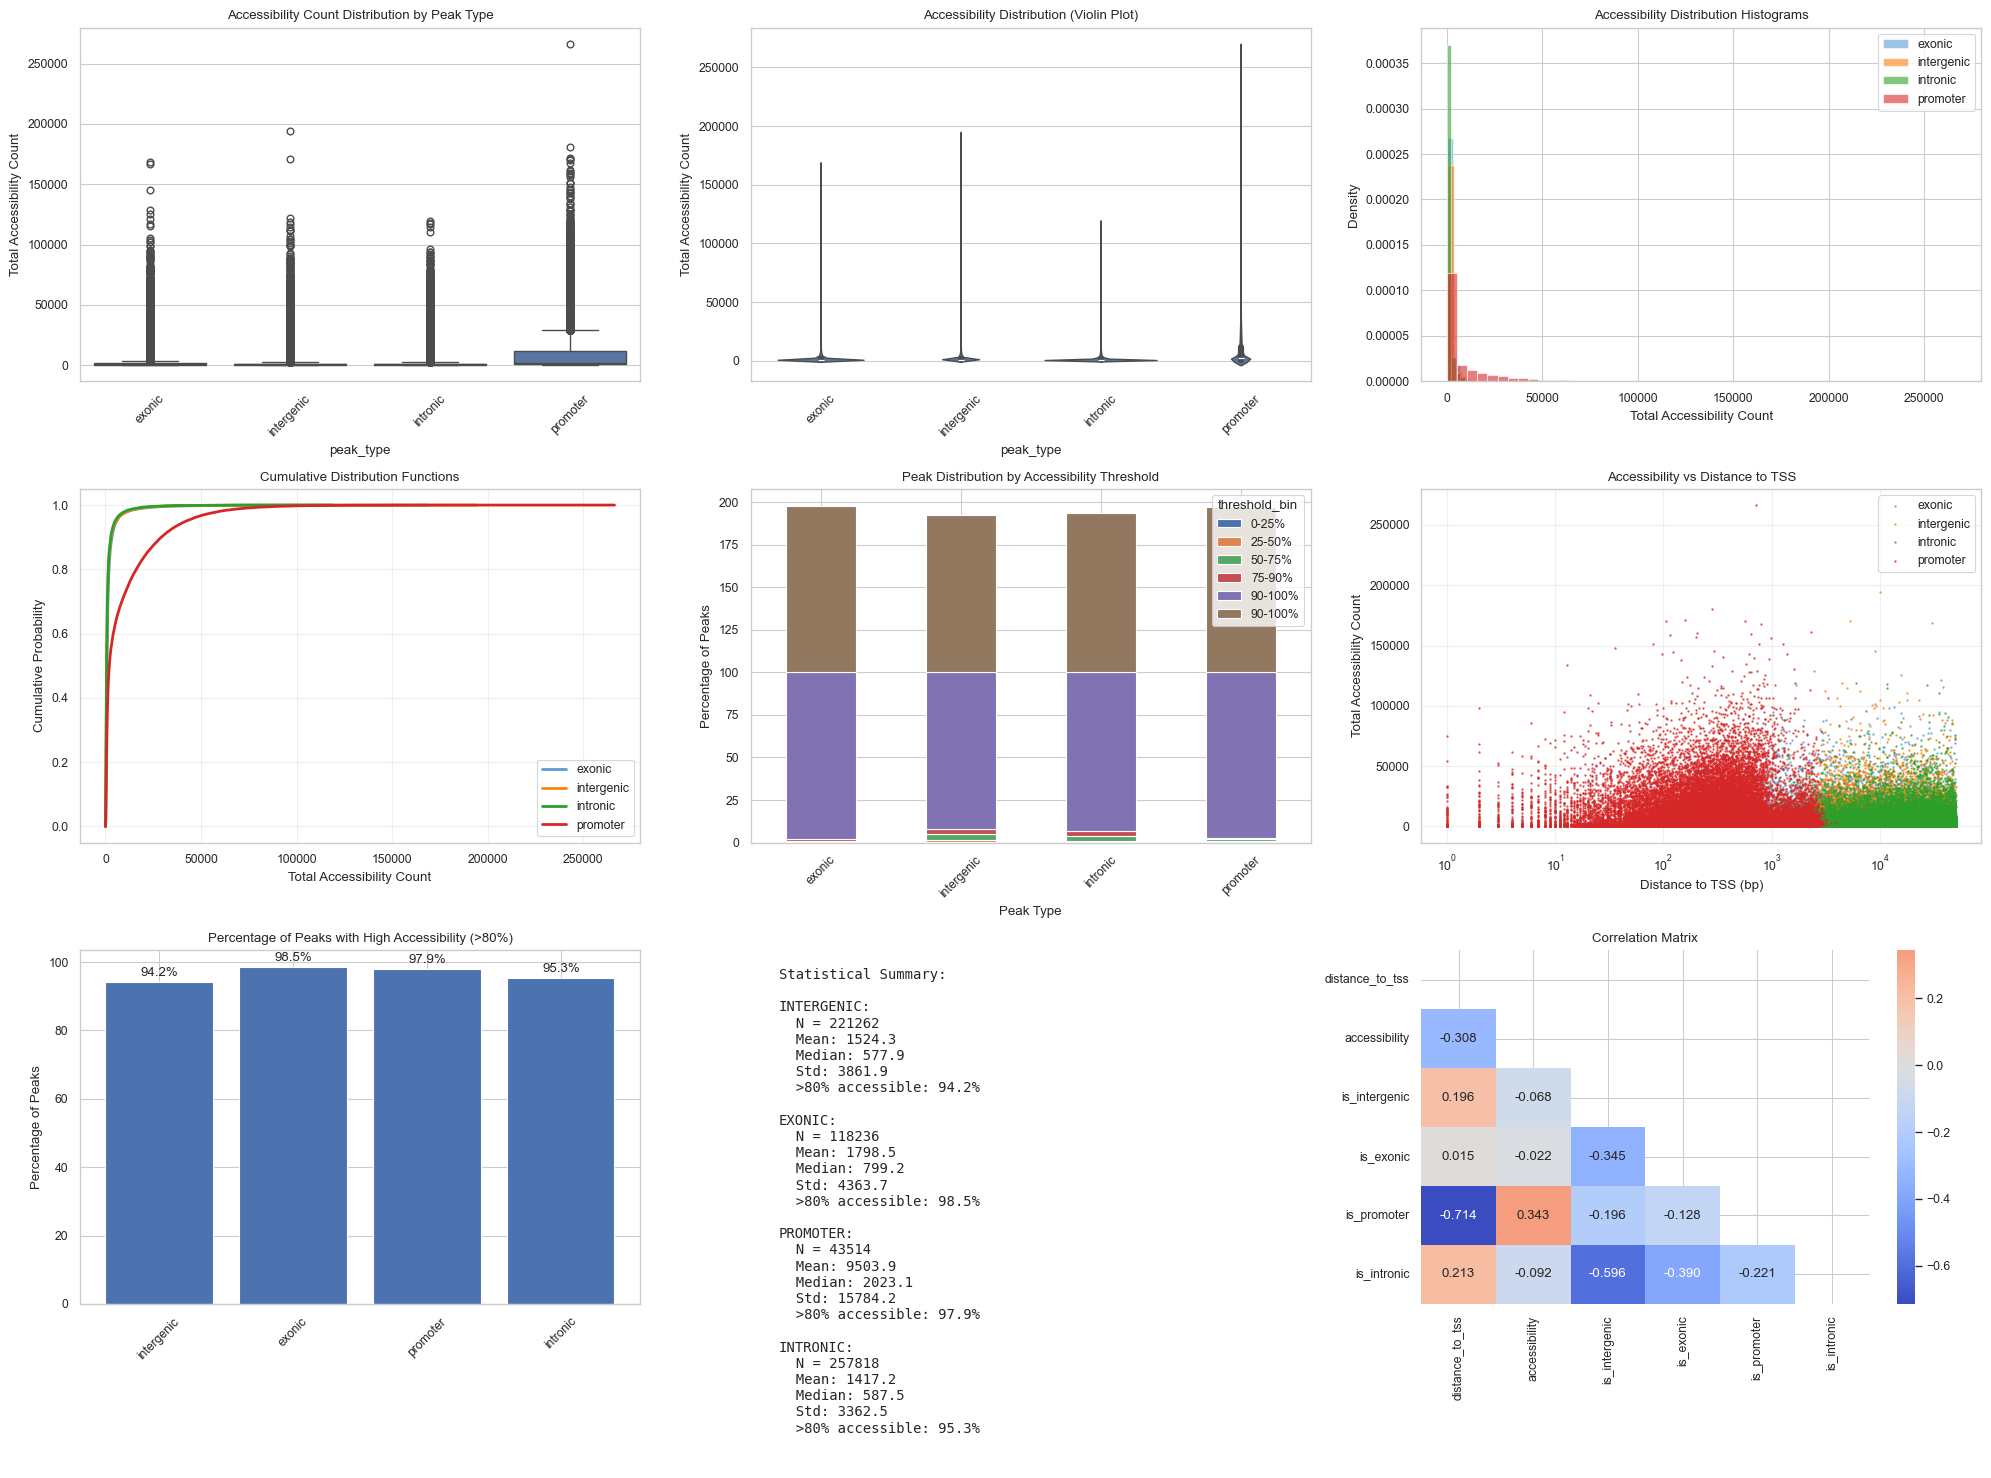


STATISTICAL TESTS:

Promoter vs intergenic:
  Mann-Whitney U p-value: 0.00e+00
  Cohen's d (effect size): 1.092
  KS test p-value: 0.00e+00

Promoter vs exonic:
  Mann-Whitney U p-value: 0.00e+00
  Cohen's d (effect size): 0.856
  KS test p-value: 0.00e+00

Promoter vs intronic:
  Mann-Whitney U p-value: 0.00e+00
  Cohen's d (effect size): 1.197
  KS test p-value: 0.00e+00


In [118]:
# Usage:
result_data, threshold_results, fig = comprehensive_accessibility_analysis(
    adata_peaks_ct_tp, 
    peak_type_col='peak_type',  # adjust this
    total_conditions=190  # 32 celltypes × 6 timepoints
)

In [119]:
# save the figure
fig.savefig(figpath + "total_accessibility_peak_type.pdf")

In [99]:
result_data

,peak_type,accessibility_count
1-32-526,intergenic,311.616681
1-2372-3057,intergenic,983.543224
1-3427-4032,intergenic,2433.226223
1-4469-7268,exonic,20954.141645
1-9541-9969,promoter,4212.425412
...,...,...
25-37496420-37496948,exonic,894.143388
25-37497049-37497789,intronic,1301.657745
25-37498106-37500090,intronic,5324.868737
25-37500598-37500859,intronic,442.481276


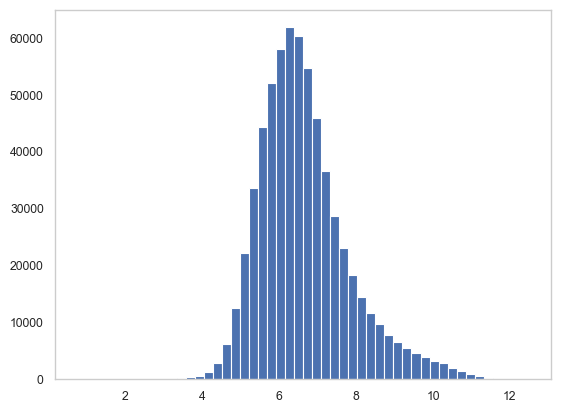

In [112]:
plt.hist(np.log(adata_peaks_ct_tp.obs["total_celltype_accessibility"]), bins=50)
# plt.xscale("log")
plt.grid(False)
plt.show()

In [29]:
adata_peaks_ct_tp.obs["log_total_accessibility"] = np.log(adata_peaks_ct_tp.obs["total_celltype_accessibility"])

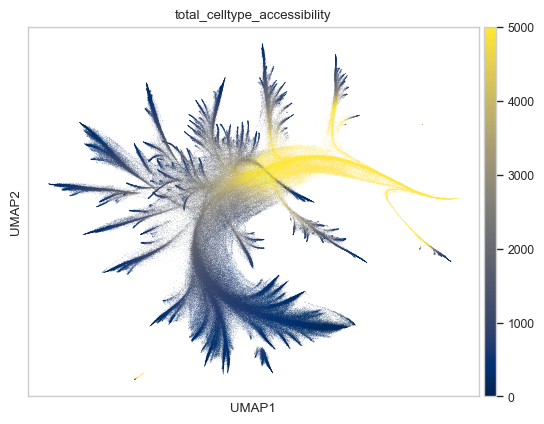

In [28]:
sc.pl.umap(adata_peaks_ct_tp, color="total_celltype_accessibility", vmin=0, vmax=5000, color_map="cividis")

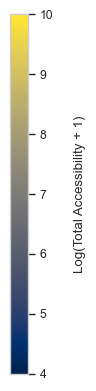

In [145]:
import matplotlib.colors as colors

# Create standalone colorbar
fig, ax = plt.subplots(figsize=(0.8, 4))

# Set up colorbar with your values
norm = colors.Normalize(vmin=4, vmax=10)
sm = plt.cm.ScalarMappable(cmap='cividis', norm=norm)
sm.set_array([])

# Create colorbar
cbar = plt.colorbar(sm, ax=ax, fraction=1.0, aspect=20)
cbar.set_label('Log(Total Accessibility + 1)', rotation=90, labelpad=15)

# Remove main axes (only want colorbar)
ax.remove()

# Save as PDF
plt.tight_layout()
plt.savefig('cividis_colorbar.pdf', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

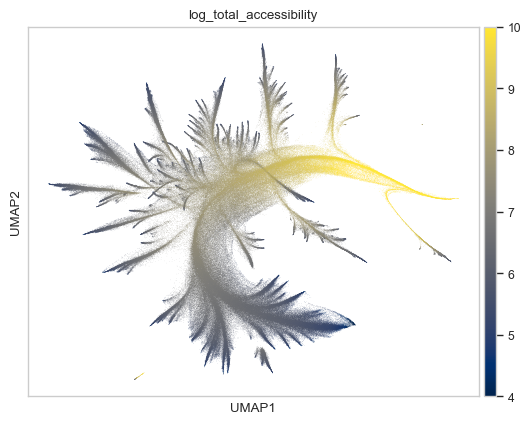

In [30]:
sc.pl.umap(adata_peaks_ct_tp, color="log_total_accessibility", 
           vmin=4, vmax=10, color_map="cividis")#,
           # save="_log_total_access.png")

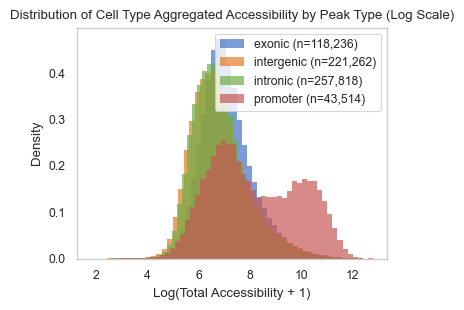

SUMMARY STATISTICS (Log-transformed vs Raw):

EXONIC:
  Count: 118,236
  Raw  - Mean: 2532.6, Median: 1090.0
  Log  - Mean: 7.131, Median: 6.995
  Raw  - Range: 12 to 238292
  Log  - Range: 2.565 to 12.381

INTERGENIC:
  Count: 221,262
  Raw  - Mean: 2148.2, Median: 776.0
  Log  - Mean: 6.813, Median: 6.655
  Raw  - Range: 5 to 250423
  Log  - Range: 1.792 to 12.431

INTRONIC:
  Count: 257,818
  Raw  - Mean: 2010.8, Median: 794.0
  Log  - Mean: 6.825, Median: 6.678
  Raw  - Range: 8 to 169854
  Log  - Range: 2.197 to 12.043

PROMOTER:
  Count: 43,514
  Raw  - Mean: 13417.8, Median: 2817.0
  Log  - Mean: 8.215, Median: 7.944
  Raw  - Range: 17 to 364844
  Log  - Range: 2.890 to 12.807


In [31]:
# Your color scheme
color_map = {
    'exonic': '#4472C4',      # blue
    'intergenic': '#E07C24',  # orange  
    'intronic': '#70AD47',    # green
    'promoter': '#C65854'     # red
}

# Log-transform the accessibility values
adata_peaks_ct_tp.obs['log_total_accessibility'] = np.log1p(adata_peaks_ct_tp.obs['total_celltype_accessibility'])

# Plot 1: Cell type aggregated accessibility (LOG-TRANSFORMED)
plt.figure(figsize=(4, 3))
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type'] == peak_type]
    plt.hist(subset['log_total_accessibility'], bins=50, alpha=0.7, density=True,
             label=f'{peak_type} (n={len(subset):,})', 
             color=color_map[peak_type], edgecolor="none", linewidth=0)

plt.xlabel('Log(Total Accessibility + 1)')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of Cell Type Aggregated Accessibility by Peak Type (Log Scale)')
# plt.yscale('log')  # Remove this since we're now plotting log-transformed data
plt.grid(False)
# plt.grid(True, alpha=0.3)  # Uncomment if you want grid
# plt.savefig(figpath + "log_total_accessibility_by_peak_type.pdf")
plt.show()

# Print summary statistics for comparison
print("SUMMARY STATISTICS (Log-transformed vs Raw):")
print("="*60)
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type'] == peak_type]
    raw_values = subset['total_celltype_accessibility']
    log_values = subset['log_total_accessibility']
    
    print(f"\n{peak_type.upper()}:")
    print(f"  Count: {len(subset):,}")
    print(f"  Raw  - Mean: {raw_values.mean():.1f}, Median: {raw_values.median():.1f}")
    print(f"  Log  - Mean: {log_values.mean():.3f}, Median: {log_values.median():.3f}")
    print(f"  Raw  - Range: {raw_values.min():.0f} to {raw_values.max():.0f}")
    print(f"  Log  - Range: {log_values.min():.3f} to {log_values.max():.3f}")

In [35]:
peaks_promoters = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type'] == "promoter"]
peaks_promoters.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,length,gene_body_overlaps,nearest_gene,distance_to_tss,leiden_coarse,n_timepoints_accessible,n_celltypes_accessible,total_celltype_accessibility,total_timepoint_accessibility,log_total_accessibility
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,428,rpl24,cep97,2066.0,33,6,32,6442.0,6442.0,8.770750
1-11007-12962,188,376.110526,1.052632,71461.0,1289.446925,1268.630750,1240.574151,1509.743769,1535.323763,1352.684285,...,1955,"cep97,rpl24",cep97,163.0,26,6,32,71461.0,71461.0,11.176921
1-13276-13705,174,27.289474,8.421053,5185.0,101.063862,82.648457,145.635609,203.659753,111.865072,97.993865,...,429,cep97,rpl24,1463.0,33,6,32,5185.0,5185.0,8.553718
1-16762-17233,188,117.478947,1.052632,22321.0,509.059695,522.222654,452.522694,341.101766,552.825133,490.697130,...,471,,nfkbiz,1718.0,26,6,32,22321.0,22321.0,10.013328
1-17587-18215,184,73.626316,3.157895,13989.0,292.150692,375.525122,243.925967,237.358955,309.208484,289.185064,...,628,,nfkbiz,814.0,26,6,32,13989.0,13989.0,9.546098


In [39]:
promoters_low = peaks_promoters[peaks_promoters.log_total_accessibility<9]
promoters_low["gene_body_overlaps"].unique()

['rpl24', 'cep97', 'FP067451.1,f7l', 'f7l', 'f7', ..., 'ldlrad3', 'cd44b', 'pdhx', 'slc10a3', 'CABZ01088346.1']
Length: 13351
Categories (30767, object): ['', 'ABCA7', 'ABCA7,APBA3', 'ABCC5', ..., 'zyg11', 'zyx', 'zzef1', 'zzz3']

In [40]:
promoteres_high = peaks_promoters[peaks_promoters.log_total_accessibility>=9]
promoteres_high["gene_body_overlaps"].unique()

['cep97,rpl24', '', 'nfkbiz', 'CU651657.1,eed', 'hikeshi', ..., 'FO834799.1', 'ZNF276', 'FO834799.2', 'CABZ01095001.1', 'CABZ01088346.1,psma1']
Length: 13687
Categories (30767, object): ['', 'ABCA7', 'ABCA7,APBA3', 'ABCC5', ..., 'zyg11', 'zyx', 'zzef1', 'zzz3']

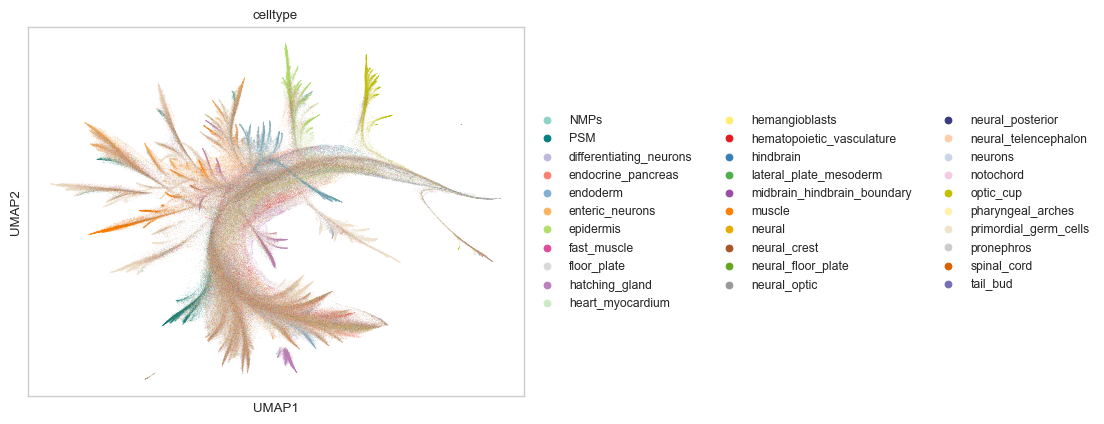

In [148]:
sc.pl.umap(adata_peaks, color="celltype", save="_most_access_celltype.png")

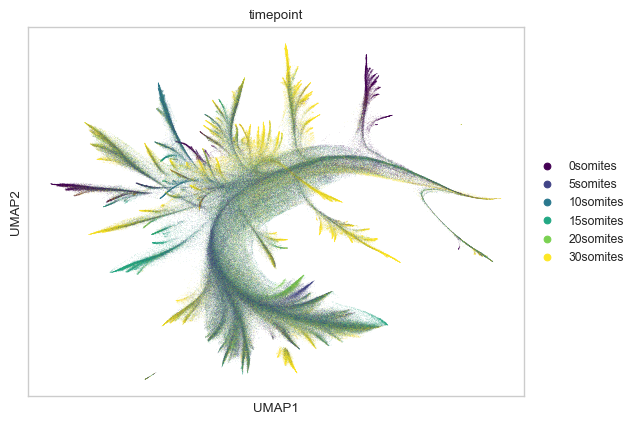

In [149]:
sc.pl.umap(adata_peaks, color="timepoint", save="_most_access_timepoint.png")

In [12]:
adata_peaks_ct_tp

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

## Take 2: 

In [43]:
# Analyze accessibility vs distance for each peak type
def analyze_distance_accessibility_relationship(adata_peaks_ct_tp):
    """Examine how distance to TSS affects accessibility patterns"""
    
    # Create distance bins
    distance_bins = [0, 1000, 5000, 10000, 50000, 100000, float('inf')]
    bin_labels = ['<1kb', '1-5kb', '5-10kb', '10-50kb', '50-100kb', '>100kb']
    
    adata_peaks_ct_tp.obs['distance_bin'] = pd.cut(
        adata_peaks_ct_tp.obs['distance_to_tss'], 
        bins=distance_bins, 
        labels=bin_labels
    )
    
    # Analyze accessibility by distance and peak type
    accessibility_by_distance = []
    for peak_type in ['promoter', 'exonic', 'intronic', 'intergenic']:
        for dist_bin in bin_labels:
            mask = (adata_peaks_ct_tp.obs['peak_type'] == peak_type) & \
                   (adata_peaks_ct_tp.obs['distance_bin'] == dist_bin)
            
            if mask.sum() > 0:
                mean_access = adata_peaks_ct_tp.obs[mask]['total_celltype_accessibility'].mean()
                accessibility_by_distance.append({
                    'peak_type': peak_type,
                    'distance_bin': dist_bin,
                    'mean_accessibility': mean_access,
                    'n_peaks': mask.sum()
                })
    
    return pd.DataFrame(accessibility_by_distance)

accessibility_by_distance = analyze_distance_accessibility_relationship(adata_peaks_ct_tp)
accessibility_by_distance.head()

,peak_type,distance_bin,mean_accessibility,n_peaks
0,promoter,<1kb,18001.200883,28524
1,promoter,1-5kb,4670.905742,14959
2,exonic,<1kb,4590.900683,1903
3,exonic,1-5kb,3330.822971,21906
4,exonic,5-10kb,2393.157657,25029


In [48]:
accessibility_by_distance

,peak_type,distance_bin,mean_accessibility,n_peaks
0,promoter,<1kb,18001.200883,28524
1,promoter,1-5kb,4670.905742,14959
2,exonic,<1kb,4590.900683,1903
3,exonic,1-5kb,3330.822971,21906
4,exonic,5-10kb,2393.157657,25029
5,exonic,10-50kb,2257.102591,57315
6,intronic,<1kb,1567.612346,1215
7,intronic,1-5kb,2336.473191,25700
8,intronic,5-10kb,1962.052135,35389
9,intronic,10-50kb,2016.383027,131855


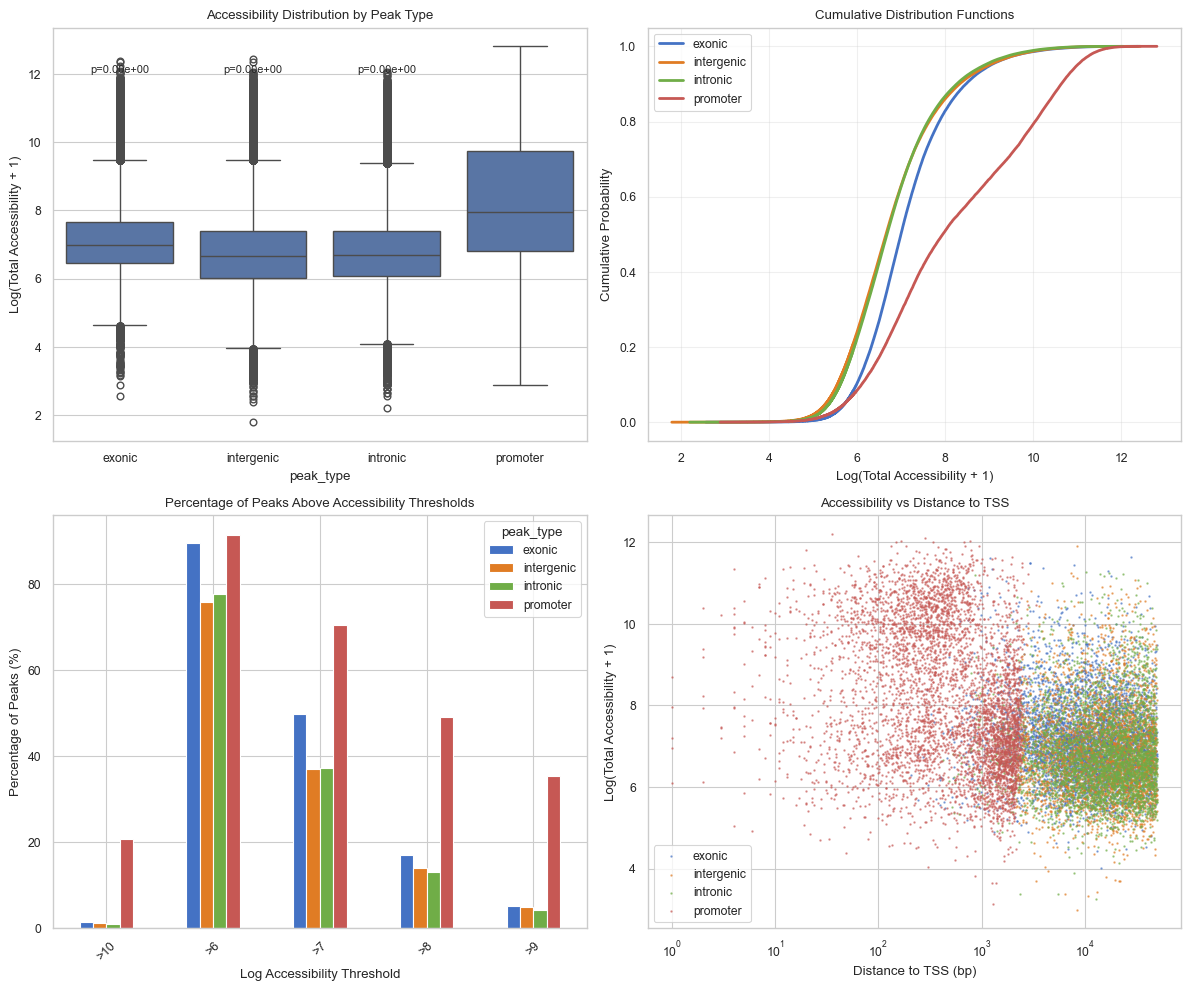

In [50]:
def create_accessibility_comparison_panel(adata_peaks_ct_tp):
    """Statistical comparison showing promoters are more accessible"""
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # D1: Box plots with statistical tests
    ax = axes[0,0]
    plot_data = pd.DataFrame({
        'peak_type': adata_peaks_ct_tp.obs['peak_type'],
        'log_accessibility': adata_peaks_ct_tp.obs['log_total_accessibility']
    })
    
    sns.boxplot(data=plot_data, x='peak_type', y='log_accessibility', ax=ax)
    ax.set_title('Accessibility Distribution by Peak Type')
    ax.set_ylabel('Log(Total Accessibility + 1)')
    
    # Add statistical annotations
    from scipy.stats import mannwhitneyu
    promoter_vals = plot_data[plot_data['peak_type'] == 'promoter']['log_accessibility']
    
    for i, peak_type in enumerate(['exonic', 'intergenic', 'intronic']):
        other_vals = plot_data[plot_data['peak_type'] == peak_type]['log_accessibility']
        stat, p_val = mannwhitneyu(promoter_vals, other_vals, alternative='greater')
        ax.text(i, ax.get_ylim()[1] * 0.9, f'p={p_val:.2e}', ha='center', fontsize=8)
    
    # D2: Cumulative Distribution Functions
    ax = axes[0,1]
    colors = {'exonic': '#4472C4', 'intergenic': '#E07C24', 'intronic': '#70AD47', 'promoter': '#C65854'}
    
    for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
        mask = adata_peaks_ct_tp.obs['peak_type'] == peak_type
        values = adata_peaks_ct_tp.obs[mask]['log_total_accessibility'].sort_values()
        y = np.arange(1, len(values) + 1) / len(values)
        ax.plot(values, y, label=peak_type, color=colors[peak_type], linewidth=2)
    
    ax.set_xlabel('Log(Total Accessibility + 1)')
    ax.set_ylabel('Cumulative Probability')
    ax.set_title('Cumulative Distribution Functions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # D3: High accessibility thresholds
    ax = axes[1,0]
    thresholds = [6, 7, 8, 9, 10]  # Based on your log scale
    threshold_data = []
    
    for threshold in thresholds:
        for peak_type in colors.keys():
            mask = adata_peaks_ct_tp.obs['peak_type'] == peak_type
            high_access_count = (adata_peaks_ct_tp.obs[mask]['log_total_accessibility'] > threshold).sum()
            total_count = mask.sum()
            percentage = (high_access_count / total_count) * 100
            
            threshold_data.append({
                'threshold': f'>{threshold}',
                'peak_type': peak_type,
                'percentage': percentage
            })
    
    threshold_df = pd.DataFrame(threshold_data)
    pivot_df = threshold_df.pivot(index='threshold', columns='peak_type', values='percentage')
    
    pivot_df.plot(kind='bar', ax=ax, color=[colors[col] for col in pivot_df.columns])
    ax.set_title('Percentage of Peaks Above Accessibility Thresholds')
    ax.set_ylabel('Percentage of Peaks (%)')
    ax.set_xlabel('Log Accessibility Threshold')
    plt.setp(ax.get_xticklabels(), rotation=45)
    
    # D4: Distance vs Accessibility
    ax = axes[1,1]
    for peak_type in colors.keys():
        mask = adata_peaks_ct_tp.obs['peak_type'] == peak_type
        x = np.abs(adata_peaks_ct_tp.obs[mask]['distance_to_tss'])
        y = adata_peaks_ct_tp.obs[mask]['log_total_accessibility']
        
        # Subsample for plotting if too many points
        if len(x) > 5000:
            idx = np.random.choice(len(x), 5000, replace=False)
            x, y = x.iloc[idx], y.iloc[idx]
        
        ax.scatter(x, y, alpha=0.5, s=1, label=peak_type, color=colors[peak_type])
    
    ax.set_xscale('log')
    ax.set_xlabel('Distance to TSS (bp)')
    ax.set_ylabel('Log(Total Accessibility + 1)')
    ax.set_title('Accessibility vs Distance to TSS')
    ax.legend()
    
    plt.tight_layout()
    return fig

fig = create_accessibility_comparison_panel(adata_peaks_ct_tp)


PROMOTER PEAK DISTANCE ANALYSIS:
Total promoter peaks: 43,514
Exactly at TSS (distance=0): 31
Within 500bp: 21,490
Within 1kb: 28,555
Within 2kb: 39,809
Beyond 2kb: 3,705


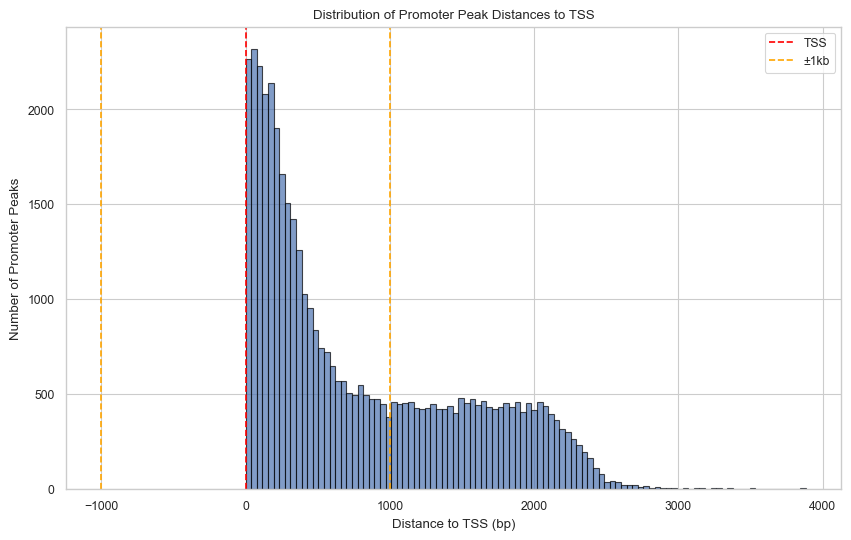

In [53]:
# Check how promoter peaks were defined
def analyze_promoter_annotation(adata_peaks_ct_tp):
    """Analyze how promoter peaks were annotated"""
    
    # Look at distance distribution for promoter peaks
    promoter_mask = adata_peaks_ct_tp.obs['peak_type'] == 'promoter'
    promoter_distances = adata_peaks_ct_tp.obs[promoter_mask]['distance_to_tss']
    
    print("PROMOTER PEAK DISTANCE ANALYSIS:")
    print(f"Total promoter peaks: {promoter_mask.sum():,}")
    print(f"Exactly at TSS (distance=0): {(promoter_distances == 0).sum():,}")
    print(f"Within 500bp: {(abs(promoter_distances) <= 500).sum():,}")
    print(f"Within 1kb: {(abs(promoter_distances) <= 1000).sum():,}")
    print(f"Within 2kb: {(abs(promoter_distances) <= 2000).sum():,}")
    print(f"Beyond 2kb: {(abs(promoter_distances) > 2000).sum():,}")
    
    # Plot distribution
    plt.figure(figsize=(10, 6))
    plt.hist(promoter_distances, bins=100, alpha=0.7, edgecolor='black')
    plt.axvline(0, color='red', linestyle='--', label='TSS')
    plt.axvline(-1000, color='orange', linestyle='--', label='±1kb')
    plt.axvline(1000, color='orange', linestyle='--')
    plt.xlabel('Distance to TSS (bp)')
    plt.ylabel('Number of Promoter Peaks')
    plt.title('Distribution of Promoter Peak Distances to TSS')
    plt.legend()
    plt.show()
    
    return promoter_distances

promoter_distances = analyze_promoter_annotation(adata_peaks_ct_tp)

## Using the Argelaguet definition of "promoter" peaks (500bp upstream, 100bp downstream from the TSS)

- 

In [55]:
anno = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/all_peaks_annotated.csv")
anno.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,distance_to_tss,leiden_coarse,linked_gene,link_score,link_zscore,link_pvalue,associated_gene,association_type,log_total_counts,peak_type_argelaguet
0,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,11542.0,7,NaN,NaN,NaN,NaN,NaN,none,6.238325,intergenic
1,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,9107.0,12,NaN,NaN,NaN,NaN,NaN,none,7.362645,intergenic
2,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,8092.0,33,NaN,NaN,NaN,NaN,NaN,none,8.172164,intergenic
3,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,5953.0,26,NaN,NaN,NaN,NaN,rpl24,overlap,10.323743,exonic
4,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,2066.0,33,NaN,NaN,NaN,NaN,rpl24,overlap,8.770594,exonic


In [61]:
adata_peaks_ct_tp.obs["peak_type_argelaguet"] = anno["peak_type_argelaguet"].values

In [62]:
adata_peaks_ct_tp.obs["peak_type_argelaguet"]

1-32-526                intergenic
1-2372-3057             intergenic
1-3427-4032             intergenic
1-4469-7268                 exonic
1-9541-9969                 exonic
                           ...    
25-37496420-37496948        exonic
25-37497049-37497789      intronic
25-37498106-37500090      intronic
25-37500598-37500859      intronic
25-37501104-37501839      promoter
Name: peak_type_argelaguet, Length: 640830, dtype: object

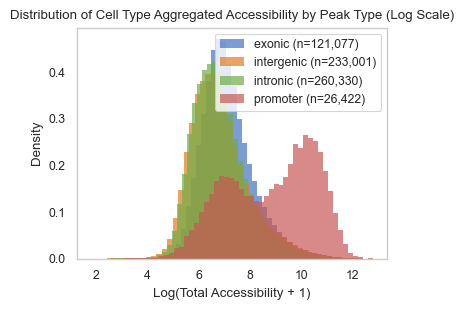

SUMMARY STATISTICS (Log-transformed vs Raw):

EXONIC:
  Count: 121,077
  Raw  - Mean: 2574.2, Median: 1098.0
  Log  - Mean: 7.139, Median: 7.002
  Raw  - Range: 12 to 238292
  Log  - Range: 2.565 to 12.381

INTERGENIC:
  Count: 233,001
  Raw  - Mean: 2232.1, Median: 793.0
  Log  - Mean: 6.837, Median: 6.677
  Raw  - Range: 5 to 250423
  Log  - Range: 1.792 to 12.431

INTRONIC:
  Count: 260,330
  Raw  - Mean: 2018.0, Median: 796.0
  Log  - Mean: 6.827, Median: 6.681
  Raw  - Range: 8 to 169854
  Log  - Range: 2.197 to 12.043

PROMOTER:
  Count: 26,422
  Raw  - Mean: 19678.8, Median: 8979.5
  Log  - Mean: 8.823, Median: 9.103
  Raw  - Range: 21 to 364844
  Log  - Range: 3.091 to 12.807


In [64]:
# Your color scheme
color_map = {
    'exonic': '#4472C4',      # blue
    'intergenic': '#E07C24',  # orange  
    'intronic': '#70AD47',    # green
    'promoter': '#C65854'     # red
}

# Log-transform the accessibility values
adata_peaks_ct_tp.obs['log_total_accessibility'] = np.log1p(adata_peaks_ct_tp.obs['total_celltype_accessibility'])

# Plot 1: Cell type aggregated accessibility (LOG-TRANSFORMED)
plt.figure(figsize=(4, 3))
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type_argelaguet'] == peak_type]
    plt.hist(subset['log_total_accessibility'], bins=50, alpha=0.7, density=True,
             label=f'{peak_type} (n={len(subset):,})', 
             color=color_map[peak_type], edgecolor="none", linewidth=0)

plt.xlabel('Log(Total Accessibility + 1)')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of Cell Type Aggregated Accessibility by Peak Type (Log Scale)')
# plt.yscale('log')  # Remove this since we're now plotting log-transformed data
plt.grid(False)
# plt.grid(True, alpha=0.3)  # Uncomment if you want grid
plt.savefig(figpath + "log_total_accessibility_by_peak_type_argelaguet.pdf")
plt.show()

# Print summary statistics for comparison
print("SUMMARY STATISTICS (Log-transformed vs Raw):")
print("="*60)
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type_argelaguet'] == peak_type]
    raw_values = subset['total_celltype_accessibility']
    log_values = subset['log_total_accessibility']
    
    print(f"\n{peak_type.upper()}:")
    print(f"  Count: {len(subset):,}")
    print(f"  Raw  - Mean: {raw_values.mean():.1f}, Median: {raw_values.median():.1f}")
    print(f"  Log  - Mean: {log_values.mean():.3f}, Median: {log_values.median():.3f}")
    print(f"  Raw  - Range: {raw_values.min():.0f} to {raw_values.max():.0f}")
    print(f"  Log  - Range: {log_values.min():.3f} to {log_values.max():.3f}")

In [84]:
# (1) use k-means clusterin with n=3
from sklearn.cluster import KMeans
import numpy as np

# Use K-means to find 3 natural clusters
accessibility_data = adata_peaks_ct_tp.obs['n_celltypes_accessible'].values.reshape(-1, 1)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(accessibility_data)
cluster_centers = kmeans.cluster_centers_.flatten()

# Sort cluster centers to assign low/medium/high
sorted_centers = np.sort(cluster_centers)
print(f"\nK-means cluster centers: {sorted_centers}")

# Find boundaries between clusters
boundaries = []
for i in range(len(sorted_centers)-1):
    boundary = (sorted_centers[i] + sorted_centers[i+1]) / 2
    boundaries.append(boundary)

print(f"K-means suggested thresholds:")
print(f"Low: ≤ {boundaries[0]:.1f} cell types")
print(f"Medium: {boundaries[0]:.1f}-{boundaries[1]:.1f} cell types")
print(f"High: > {boundaries[1]:.1f} cell types")

# Add cluster labels to your data
adata_peaks_ct_tp.obs['accessibility_cluster_kmeans'] = clusters


K-means cluster centers: [ 2.57398721 12.94912795 29.77677533]
K-means suggested thresholds:
Low: ≤ 7.8 cell types
Medium: 7.8-21.4 cell types
High: > 21.4 cell types


In [85]:
# use the Gaussian mixture model (n=3)
from sklearn.mixture import GaussianMixture

# Fit Gaussian Mixture Model with 3 components
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_clusters = gmm.fit_predict(accessibility_data)
gmm_means = gmm.means_.flatten()

sorted_gmm_means = np.sort(gmm_means)
print(f"\nGaussian Mixture Model means: {sorted_gmm_means}")

# Calculate boundaries based on GMM
gmm_boundaries = []
for i in range(len(sorted_gmm_means)-1):
    boundary = (sorted_gmm_means[i] + sorted_gmm_means[i+1]) / 2
    gmm_boundaries.append(boundary)

print(f"GMM suggested thresholds:")
print(f"Low: ≤ {gmm_boundaries[0]:.1f} cell types")
print(f"Medium: {gmm_boundaries[0]:.1f}-{gmm_boundaries[1]:.1f} cell types")
print(f"High: > {gmm_boundaries[1]:.1f} cell types")

adata_peaks_ct_tp.obs['accessibility_cluster_gmm'] = gmm_clusters


Gaussian Mixture Model means: [ 2.29610954 14.55397077 32.        ]
GMM suggested thresholds:
Low: ≤ 8.4 cell types
Medium: 8.4-23.3 cell types
High: > 23.3 cell types


In [86]:
from skimage.filters import threshold_otsu

# For bimodal distribution, use Otsu's method to find optimal threshold
accessibility_values = adata_peaks_ct_tp.obs['n_celltypes_accessible'].values

# Otsu works on image data, so we need to create a histogram
hist, bin_edges = np.histogram(accessibility_values, bins=50)
otsu_threshold = threshold_otsu(accessibility_values)

print(f"\nOtsu's threshold: {otsu_threshold:.1f}")
print("This separates the bimodal distribution optimally")

# For 3 categories, you could use Otsu + additional logic
# Split the high accessibility group further
high_accessibility = accessibility_values[accessibility_values > otsu_threshold]
if len(high_accessibility) > 100:  # Only if we have enough high-accessibility peaks
    high_otsu = threshold_otsu(high_accessibility)
    print(f"Secondary threshold for high group: {high_otsu:.1f}")


Otsu's threshold: 15.0
This separates the bimodal distribution optimally
Secondary threshold for high group: 25.0


In [87]:
# Check what percentage of peaks fall into different threshold schemes
print("Comparison of different high-accessibility thresholds:")

for threshold in [15, 20, 25, 30]:
    high_count = (adata_peaks_ct_tp.obs['n_celltypes_accessible'] > threshold).sum()
    high_pct = high_count / len(adata_peaks_ct_tp.obs) * 100
    print(f"Threshold > {threshold}: {high_count:,} peaks ({high_pct:.1f}%)")

print(f"\nMax cell types in dataset: {adata_peaks_ct_tp.obs['n_celltypes_accessible'].max()}")
print(f"95th percentile: {adata_peaks_ct_tp.obs['n_celltypes_accessible'].quantile(0.95):.1f}")
print(f"90th percentile: {adata_peaks_ct_tp.obs['n_celltypes_accessible'].quantile(0.90):.1f}")

# Look at the distribution around 25-35 range
print(f"\nDistribution in high-accessibility range:")
for i in range(25, 36):
    count = (adata_peaks_ct_tp.obs['n_celltypes_accessible'] == i).sum()
    if count > 0:
        print(f"{i} cell types: {count:,} peaks")

Comparison of different high-accessibility thresholds:
Threshold > 15: 151,975 peaks (23.7%)
Threshold > 20: 122,806 peaks (19.2%)
Threshold > 25: 99,803 peaks (15.6%)
Threshold > 30: 74,252 peaks (11.6%)

Max cell types in dataset: 32
95th percentile: 32.0
90th percentile: 31.0

Distribution in high-accessibility range:
25 cell types: 4,437 peaks
26 cell types: 4,537 peaks
27 cell types: 4,528 peaks
28 cell types: 4,737 peaks
29 cell types: 5,357 peaks
30 cell types: 6,392 peaks
31 cell types: 10,646 peaks
32 cell types: 63,606 peaks


In [88]:
# First, let's identify high accessibility peaks using different thresholds
print("Analysis of NON-accessible cell types in high accessibility peaks:")
print("="*60)

# Get the binary accessibility matrix (celltype_df > 0 gives True/False)
celltype_binary = celltype_df > 0

for threshold in [20, 25, 30]:
    print(f"\n🔍 THRESHOLD: > {threshold} accessible cell types")
    print("-" * 50)
    
    # Get peaks that are highly accessible
    high_accessible_peaks = adata_peaks_ct_tp.obs['n_celltypes_accessible'] > threshold
    high_peaks_indices = adata_peaks_ct_tp.obs[high_accessible_peaks].index
    
    print(f"Number of high accessibility peaks: {len(high_peaks_indices):,}")
    
    if len(high_peaks_indices) > 0:
        # For these high accessibility peaks, count how often each cell type is NOT accessible
        not_accessible_counts = {}
        
        for cell_type in celltype_df.columns:
            # Count how many high accessibility peaks are NOT accessible in this cell type
            not_accessible_in_celltype = (~celltype_binary.loc[high_peaks_indices, cell_type]).sum()
            not_accessible_counts[cell_type] = not_accessible_in_celltype
        
        # Convert to percentages
        not_accessible_pct = {ct: (count/len(high_peaks_indices))*100 
                             for ct, count in not_accessible_counts.items()}
        
        # Sort by frequency of being NOT accessible
        sorted_not_accessible = sorted(not_accessible_pct.items(), 
                                     key=lambda x: x[1], reverse=True)
        
        print(f"\nCell types MOST OFTEN not accessible in high accessibility peaks:")
        print("(Cell type: % of high peaks where it's NOT accessible)")
        for cell_type, pct in sorted_not_accessible[:10]:  # Top 10
            count = not_accessible_counts[cell_type]
            print(f"  {cell_type:20}: {count:4,} peaks ({pct:5.1f}%)")
        
        print(f"\nCell types LEAST OFTEN not accessible (most universally accessible):")
        for cell_type, pct in sorted_not_accessible[-10:]:  # Bottom 10
            count = not_accessible_counts[cell_type]
            print(f"  {cell_type:20}: {count:4,} peaks ({pct:5.1f}%)")

print("\n" + "="*60)

Analysis of NON-accessible cell types in high accessibility peaks:

🔍 THRESHOLD: > 20 accessible cell types
--------------------------------------------------
Number of high accessibility peaks: 122,806

Cell types MOST OFTEN not accessible in high accessibility peaks:
(Cell type: % of high peaks where it's NOT accessible)
  primordial_germ_cells: 15,390 peaks ( 12.5%)
  neural              :   14 peaks (  0.0%)
  NMPs                :    0 peaks (  0.0%)
  PSM                 :    0 peaks (  0.0%)
  differentiating_neurons:    0 peaks (  0.0%)
  endocrine_pancreas  :    0 peaks (  0.0%)
  endoderm            :    0 peaks (  0.0%)
  enteric_neurons     :    0 peaks (  0.0%)
  epidermis           :    0 peaks (  0.0%)
  fast_muscle         :    0 peaks (  0.0%)

Cell types LEAST OFTEN not accessible (most universally accessible):
  neural_posterior    :    0 peaks (  0.0%)
  neural_telencephalon:    0 peaks (  0.0%)
  neurons             :    0 peaks (  0.0%)
  notochord           :    

In [94]:
# First, let's check the distribution thresholds for timepoints
print("Comparison of different high temporal accessibility thresholds:")

for threshold in [3, 4, 5, 6]:
    high_count = (adata_peaks_ct_tp.obs['n_timepoints_accessible'] > threshold).sum()
    high_pct = high_count / len(adata_peaks_ct_tp.obs) * 100
    print(f"Threshold > {threshold}: {high_count:,} peaks ({high_pct:.1f}%)")

print(f"\nMax timepoints in dataset: {adata_peaks_ct_tp.obs['n_timepoints_accessible'].max()}")
print(f"95th percentile: {adata_peaks_ct_tp.obs['n_timepoints_accessible'].quantile(0.95):.1f}")
print(f"90th percentile: {adata_peaks_ct_tp.obs['n_timepoints_accessible'].quantile(0.90):.1f}")

# Analysis of NON-accessible timepoints in high temporal accessibility peaks
print("\nAnalysis of NON-accessible timepoints in high temporal accessibility peaks:")
print("="*70)

# Get the binary accessibility matrix for timepoints (timepoint_df > 0 gives True/False)
timepoint_binary = timepoint_df > 0

for threshold in [4, 5, 6]:
    print(f"\n🔍 THRESHOLD: > {threshold} accessible timepoints")
    print("-" * 50)
    
    # Get peaks that are highly temporally accessible
    high_temporal_peaks = adata_peaks_ct_tp.obs['n_timepoints_accessible'] > threshold
    high_peaks_indices = adata_peaks_ct_tp.obs[high_temporal_peaks].index
    
    print(f"Number of high temporal accessibility peaks: {len(high_peaks_indices):,}")
    
    if len(high_peaks_indices) > 0:
        # For these high temporal accessibility peaks, count how often each timepoint is NOT accessible
        not_accessible_counts = {}
        
        for timepoint in timepoint_df.columns:
            # Count how many high temporal peaks are NOT accessible at this timepoint
            not_accessible_in_timepoint = (~timepoint_binary.loc[high_peaks_indices, timepoint]).sum()
            not_accessible_counts[timepoint] = not_accessible_in_timepoint
        
        # Convert to percentages
        not_accessible_pct = {tp: (count/len(high_peaks_indices))*100 
                             for tp, count in not_accessible_counts.items()}
        
        # Sort by frequency of being NOT accessible
        sorted_not_accessible = sorted(not_accessible_pct.items(), 
                                     key=lambda x: x[1], reverse=True)
        
        print(f"\nTimepoints MOST OFTEN not accessible in high temporal accessibility peaks:")
        print("(Timepoint: % of high peaks where it's NOT accessible)")
        for timepoint, pct in sorted_not_accessible:
            count = not_accessible_counts[timepoint]
            print(f"  {timepoint:15}: {count:4,} peaks ({pct:5.1f}%)")

# Detailed analysis for a specific threshold
threshold = 5
print(f"\n📊 DETAILED TIMEPOINT ANALYSIS: Peaks with > {threshold} accessible timepoints")
print("="*70)

high_temporal_peaks = adata_peaks_ct_tp.obs['n_timepoints_accessible'] > threshold
high_peaks_indices = adata_peaks_ct_tp.obs[high_temporal_peaks].index

print(f"Total high temporal accessibility peaks: {len(high_peaks_indices):,}")
print(f"Total timepoints in dataset: {len(timepoint_df.columns)}")

# Create a summary matrix for timepoints
timepoint_summary = []
for timepoint in timepoint_df.columns:
    accessible_count = timepoint_binary.loc[high_peaks_indices, timepoint].sum()
    not_accessible_count = len(high_peaks_indices) - accessible_count
    accessible_pct = (accessible_count / len(high_peaks_indices)) * 100
    
    timepoint_summary.append({
        'timepoint': timepoint,
        'timepoint_num': int(timepoint.replace('somites', '')),
        'accessible_count': accessible_count,
        'not_accessible_count': not_accessible_count,
        'accessible_pct': accessible_pct,
        'not_accessible_pct': 100 - accessible_pct
    })

timepoint_summary_df = pd.DataFrame(timepoint_summary)
timepoint_summary_df = timepoint_summary_df.sort_values('not_accessible_pct', ascending=False)

print(f"\n🚫 Timepoints that are MOST OFTEN missing from 'broadly temporal accessible' peaks:")
print(timepoint_summary_df[['timepoint', 'not_accessible_count', 'not_accessible_pct']].to_string(index=False))

# Save the timepoint summary
timepoint_summary_df.to_csv(figpath + f"timepoint_accessibility_summary_threshold{threshold}.csv", index=False)
print(f"\nTimepoint summary saved to: timepoint_accessibility_summary_threshold{threshold}.csv")

Comparison of different high temporal accessibility thresholds:
Threshold > 3: 379,109 peaks (59.2%)
Threshold > 4: 342,616 peaks (53.5%)
Threshold > 5: 314,790 peaks (49.1%)
Threshold > 6: 292,605 peaks (45.7%)

Max timepoints in dataset: 120
95th percentile: 111.0
90th percentile: 83.0

Analysis of NON-accessible timepoints in high temporal accessibility peaks:

🔍 THRESHOLD: > 4 accessible timepoints
--------------------------------------------------
Number of high temporal accessibility peaks: 342,616

Timepoints MOST OFTEN not accessible in high temporal accessibility peaks:
(Timepoint: % of high peaks where it's NOT accessible)
  30somites      :   48 peaks (  0.0%)
  20somites      :   25 peaks (  0.0%)
  5somites       :   22 peaks (  0.0%)
  0somites       :   21 peaks (  0.0%)
  10somites      :   21 peaks (  0.0%)
  15somites      :   10 peaks (  0.0%)

🔍 THRESHOLD: > 5 accessible timepoints
--------------------------------------------------
Number of high temporal accessibil

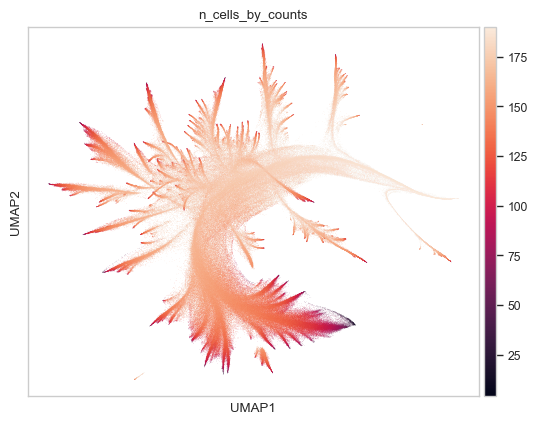

In [93]:
sc.pl.umap(adata_peaks_ct_tp, color=["n_cells_by_counts"])

### [Optional] the magnitude of accessibility (summed over groups, celltypes, or timepoints) 

In [77]:
# Get the count matrix (peaks x samples)
X = adata_peaks_ct_tp.layers["normalized"]
if hasattr(X, 'toarray'):  # If it's a sparse matrix
    X = X.toarray()
    
# Parse sample information - split on LAST underscore for celltype_timepoint format
var_info = []
for i, idx in enumerate(adata_peaks_ct_tp.var.index):
    parts = idx.rsplit('_', 1)  # Split on last underscore
    cell_type = parts[0]
    timepoint = parts[1]
    var_info.append({
        'sample_idx': i,
        'sample_id': idx, 
        'cell_type': cell_type, 
        'timepoint': timepoint
    })

var_df = pd.DataFrame(var_info)
print("Sample of parsed identifiers:")
print(var_df.head(10))

# 1. WHOLE GROUP: Sum across all samples (total accessibility)
print("1. Computing total accessibility across all samples...")
adata_peaks_ct_tp.obs['total_accessibility'] = X.sum(axis=1)
print(f"Total accessibility - mean: {adata_peaks_ct_tp.obs['total_accessibility'].mean():.2f}, max: {adata_peaks_ct_tp.obs['total_accessibility'].max()}")

# 2. AGGREGATED BY CELL TYPE: Sum across timepoints for each cell type
print("\n2. Computing accessibility aggregated by cell type...")
celltype_accessibility = {}
for cell_type in var_df['cell_type'].unique():
    # Get all sample indices for this cell type (across all timepoints)
    sample_indices = var_df[var_df['cell_type'] == cell_type]['sample_idx'].tolist()
    # Sum accessibility values for each peak across all samples from this cell type
    celltype_accessibility[cell_type] = X[:, sample_indices].sum(axis=1)

celltype_df = pd.DataFrame(celltype_accessibility, index=adata_peaks_ct_tp.obs.index)
# Sort columns alphabetically
celltype_df = celltype_df.reindex(sorted(celltype_df.columns), axis=1)

# Add total cell type accessibility (sum across all cell types)
adata_peaks_ct_tp.obs['total_celltype_accessibility'] = celltype_df.sum(axis=1)

print(f"Cell type accessibility shape: {celltype_df.shape}")
print(f"Total cell type accessibility - mean: {adata_peaks_ct_tp.obs['total_celltype_accessibility'].mean():.2f}")
print("Sample cell type accessibility matrix:")
print(celltype_df.head())

# 3. AGGREGATED BY TIMEPOINT: Sum across cell types for each timepoint  
print("\n3. Computing accessibility aggregated by timepoint...")
timepoint_accessibility = {}
for timepoint in var_df['timepoint'].unique():
    # Get all sample indices for this timepoint (across all cell types)
    sample_indices = var_df[var_df['timepoint'] == timepoint]['sample_idx'].tolist()
    # Sum accessibility values for each peak across all samples from this timepoint
    timepoint_accessibility[timepoint] = X[:, sample_indices].sum(axis=1)

timepoint_df = pd.DataFrame(timepoint_accessibility, index=adata_peaks_ct_tp.obs.index)
# Sort columns by timepoint (extract number from somites)
timepoint_order = sorted(timepoint_df.columns, key=lambda x: int(x.replace('somites', '')))
timepoint_df = timepoint_df.reindex(timepoint_order, axis=1)

# Add total timepoint accessibility (sum across all timepoints)
adata_peaks_ct_tp.obs['total_timepoint_accessibility'] = timepoint_df.sum(axis=1)

print(f"Timepoint accessibility shape: {timepoint_df.shape}")
print(f"Total timepoint accessibility - mean: {adata_peaks_ct_tp.obs['total_timepoint_accessibility'].mean():.2f}")
print("Sample timepoint accessibility matrix:")
print(timepoint_df.head())

# Verify that total accessibility equals sum of cell types equals sum of timepoints
print(f"\nVerification:")
print(f"Total accessibility mean: {adata_peaks_ct_tp.obs['total_accessibility'].mean():.2f}")
print(f"Sum of cell type accessibility mean: {adata_peaks_ct_tp.obs['total_celltype_accessibility'].mean():.2f}")
print(f"Sum of timepoint accessibility mean: {adata_peaks_ct_tp.obs['total_timepoint_accessibility'].mean():.2f}")

print(f"\nUnique timepoints: {timepoint_order}")
print(f"Unique cell types: {sorted(celltype_df.columns)}")

Sample of parsed identifiers:
   sample_idx       sample_id cell_type  timepoint
0           0   NMPs_0somites      NMPs   0somites
1           1   NMPs_5somites      NMPs   5somites
2           2  NMPs_10somites      NMPs  10somites
3           3  NMPs_15somites      NMPs  15somites
4           4  NMPs_20somites      NMPs  20somites
5           5  NMPs_30somites      NMPs  30somites
6           6    PSM_0somites       PSM   0somites
7           7    PSM_5somites       PSM   5somites
8           8   PSM_10somites       PSM  10somites
9           9   PSM_15somites       PSM  15somites
1. Computing total accessibility across all samples...
Total accessibility - mean: 2073.60, max: 266406.91192447353

2. Computing accessibility aggregated by cell type...
Cell type accessibility shape: (640830, 32)
Total cell type accessibility - mean: 2073.60
Sample cell type accessibility matrix:
                   NMPs         PSM  differentiating_neurons  \
1-32-526       7.142939   11.116312          

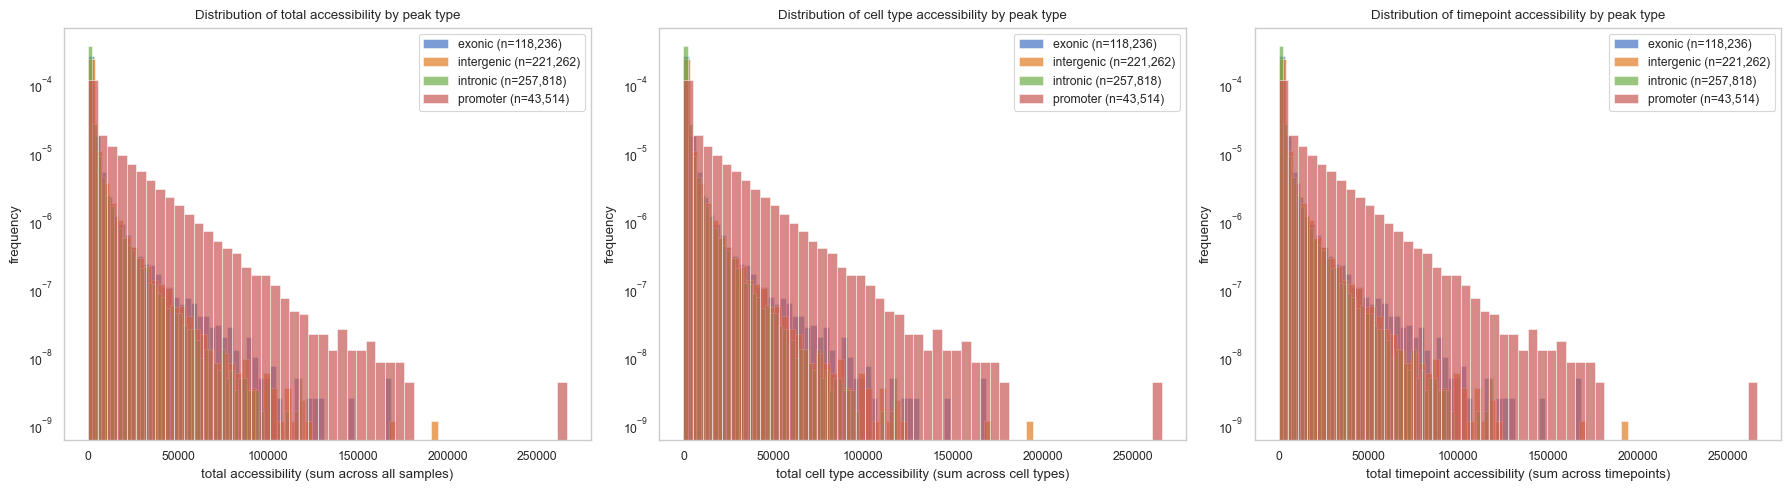

In [79]:
# Your color scheme
color_map = {
    'exonic': '#4472C4',      # blue
    'intergenic': '#E07C24',  # orange  
    'intronic': '#70AD47',    # green
    'promoter': '#C65854'     # red
}

# Create 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total accessibility across all samples
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type'] == peak_type]
    axes[0].hist(subset['total_accessibility'], bins=50, alpha=0.7, density=True,
                 label=f'{peak_type} (n={len(subset):,})', 
                 color=color_map[peak_type], edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('total accessibility (sum across all samples)')
axes[0].set_ylabel('frequency')
axes[0].legend()
axes[0].set_title('Distribution of total accessibility by peak type')
axes[0].grid(False)

# Plot 2: Total cell type accessibility (sum across cell types)
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type'] == peak_type]
    axes[1].hist(subset['total_celltype_accessibility'], bins=50, alpha=0.7, density=True,
                 label=f'{peak_type} (n={len(subset):,})', 
                 color=color_map[peak_type], edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('total cell type accessibility (sum across cell types)')
axes[1].set_ylabel('frequency')
axes[1].legend()
axes[1].set_title('Distribution of cell type accessibility by peak type')
axes[1].grid(False)

# Plot 3: Total timepoint accessibility (sum across timepoints)
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = adata_peaks_ct_tp.obs[adata_peaks_ct_tp.obs['peak_type'] == peak_type]
    axes[2].hist(subset['total_timepoint_accessibility'], bins=50, alpha=0.7, density=True,
                 label=f'{peak_type} (n={len(subset):,})', 
                 color=color_map[peak_type], edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('total timepoint accessibility (sum across timepoints)')
axes[2].set_ylabel('frequency')
axes[2].legend()
axes[2].set_title('Distribution of timepoint accessibility by peak type')
axes[2].grid(False)

axes[0].set_yscale('log')  # Set log scale
axes[1].set_yscale('log')  # Set log scale
axes[2].set_yscale('log')  # Set log scale

plt.tight_layout()
# plt.savefig(figpath + "hist_accessibility_distributions_combined.pdf")
plt.show()

In [29]:
# First, let's create a matrix of accessibility by sample and peak type
# Get the count matrix (peaks x samples)
X = adata_peaks.X
if hasattr(X, 'toarray'):  # If it's a sparse matrix
    X = X.toarray()

# Parse sample information again
var_info = []
for i, idx in enumerate(adata_peaks.var.index):
    parts = idx.split('_', 1)
    leiden_cluster = parts[0]
    timepoint = parts[1]
    var_info.append({
        'sample_idx': i,
        'sample_id': idx, 
        'leiden_cluster': leiden_cluster, 
        'timepoint': timepoint
    })

var_df = pd.DataFrame(var_info)

# Calculate accessibility rates by sample and peak type
accessibility_by_sample = []

for _, sample_info in var_df.iterrows():
    sample_idx = sample_info['sample_idx']
    sample_id = sample_info['sample_id']
    leiden_cluster = sample_info['leiden_cluster']
    timepoint = sample_info['timepoint']
    
    # Get accessibility for this sample across all peaks
    sample_accessibility = X[:, sample_idx] > 0
    
    # Calculate accessibility rate for each peak type
    for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
        peak_mask = adata_peaks.obs['peak_type'] == peak_type
        n_peaks_of_type = peak_mask.sum()
        n_accessible_peaks = (sample_accessibility & peak_mask).sum()
        accessibility_rate = n_accessible_peaks / n_peaks_of_type if n_peaks_of_type > 0 else 0
        
        accessibility_by_sample.append({
            'sample_id': sample_id,
            'leiden_cluster': leiden_cluster,
            'timepoint': timepoint,
            'peak_type': peak_type,
            'accessibility_rate': accessibility_rate,
            'n_accessible_peaks': n_accessible_peaks,
            'n_total_peaks': n_peaks_of_type
        })

accessibility_df = pd.DataFrame(accessibility_by_sample)

# Pivot to create a matrix for heatmap visualization
heatmap_data = accessibility_df.pivot_table(
    index=['leiden_cluster', 'timepoint'], 
    columns='peak_type', 
    values='accessibility_rate'
)

print("Accessibility rates by sample and peak type:")
print(heatmap_data.head(10))

Accessibility rates by sample and peak type:
peak_type                   exonic  intergenic  intronic  promoter
leiden_cluster timepoint                                          
0              0somites   0.995027    0.983273  0.985707  0.991911
               10somites  0.959995    0.916538  0.924668  0.967367
               15somites  0.993851    0.982550  0.985083  0.993427
               20somites  0.994215    0.982654  0.985172  0.991727
               30somites  0.894609    0.847484  0.840667  0.922692
               5somites   0.996600    0.988050  0.990276  0.993427
1              0somites   0.996947    0.988656  0.991032  0.994002
               10somites  0.992777    0.978853  0.981689  0.990899
               15somites  0.990764    0.975355  0.977030  0.990072
               20somites  0.944002    0.899296  0.901593  0.956887


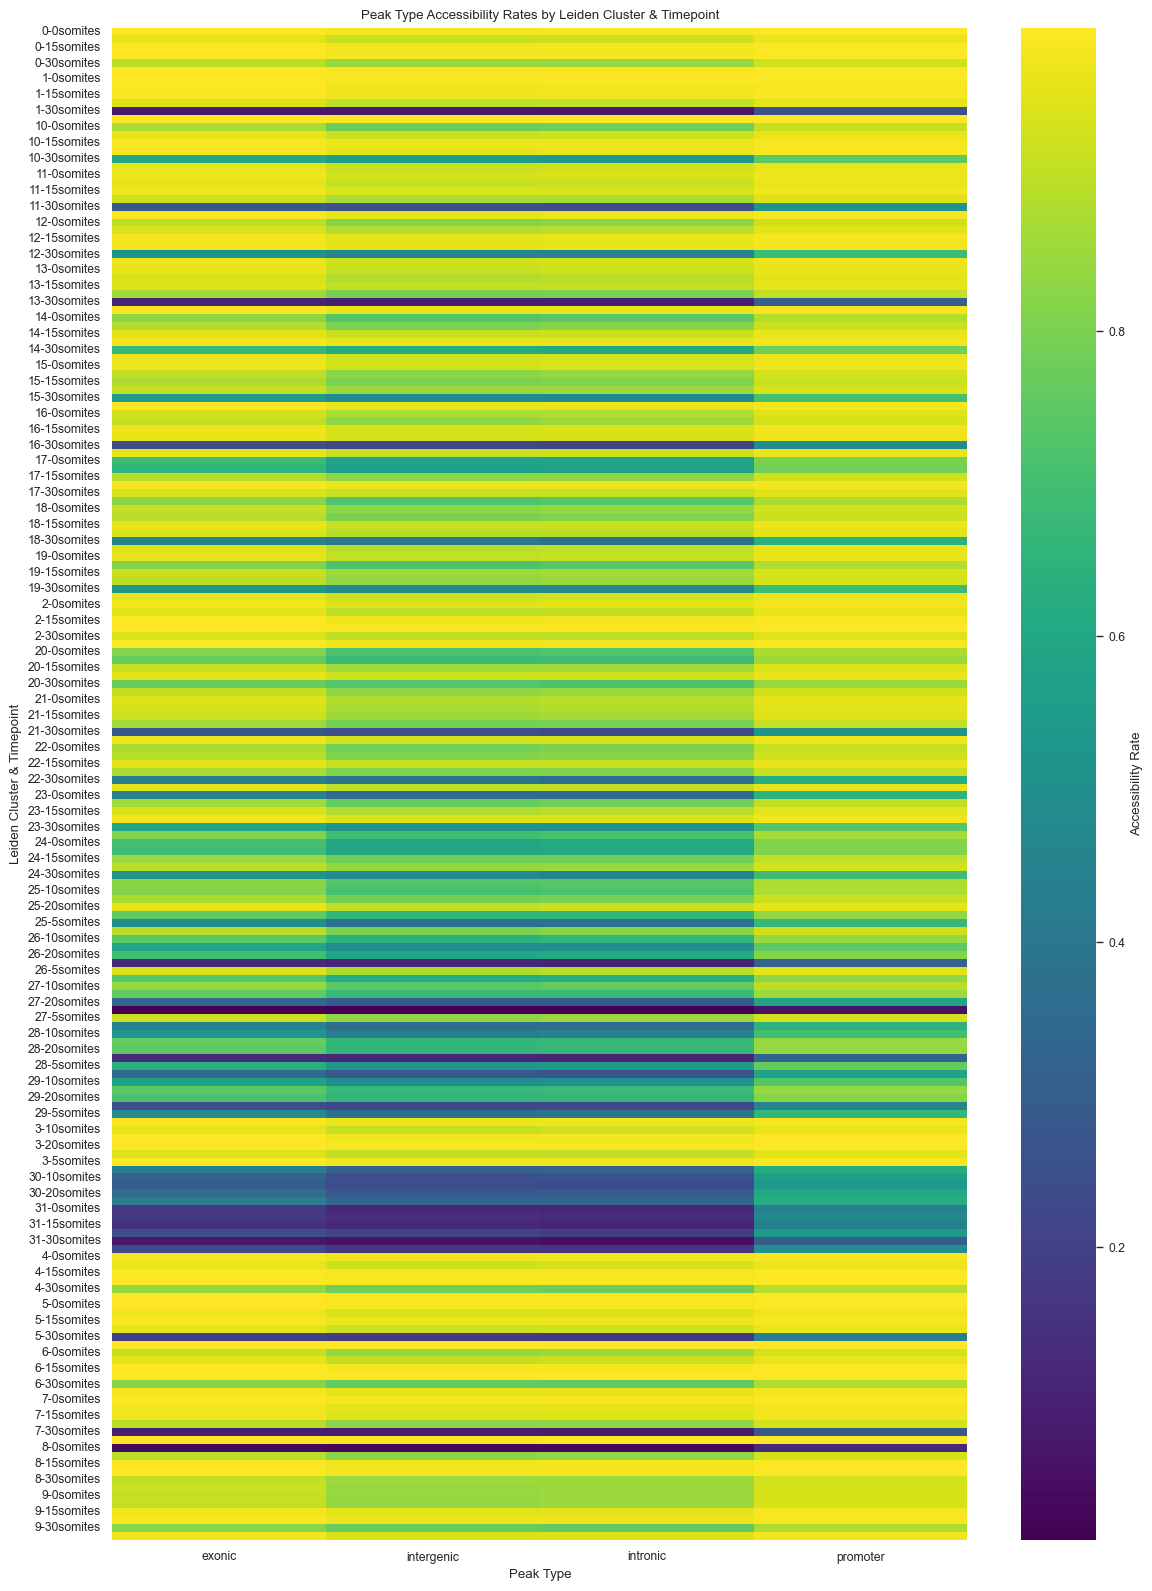


Samples with LOWEST accessibility rates for each peak type:

EXONIC - Top 10 most depleted combinations:
  27_30somites: 0.0118 (1391/118236)
  8_0somites: 0.0323 (3820/118236)
  31_30somites: 0.0669 (7910/118236)
  1_30somites: 0.0763 (9027/118236)
  7_30somites: 0.0944 (11157/118236)
  13_30somites: 0.1081 (12787/118236)
  26_30somites: 0.1228 (14520/118236)
  28_30somites: 0.1284 (15182/118236)
  31_15somites: 0.1476 (17457/118236)
  31_0somites: 0.1643 (19425/118236)

INTERGENIC - Top 10 most depleted combinations:
  27_30somites: 0.0097 (2153/221262)
  8_0somites: 0.0268 (5938/221262)
  31_30somites: 0.0572 (12665/221262)
  1_30somites: 0.0707 (15652/221262)
  7_30somites: 0.0865 (19144/221262)
  13_30somites: 0.0946 (20923/221262)
  26_30somites: 0.1094 (24203/221262)
  28_30somites: 0.1137 (25156/221262)
  31_15somites: 0.1201 (26573/221262)
  31_0somites: 0.1244 (27523/221262)

INTRONIC - Top 10 most depleted combinations:
  27_30somites: 0.0086 (2208/257818)
  8_0somites: 0.0

In [30]:
# 1. Heatmap showing accessibility rates
plt.figure(figsize=(12, 16))
sns.heatmap(heatmap_data, 
            annot=False, 
            cmap='viridis', 
            cbar_kws={'label': 'Accessibility Rate'})
plt.title('Peak Type Accessibility Rates by Leiden Cluster & Timepoint')
plt.xlabel('Peak Type')
plt.ylabel('Leiden Cluster & Timepoint')
plt.tight_layout()
plt.savefig(figpath + "heatmap_accessibility_by_sample_peak_type.pdf")
plt.show()

# 2. Find samples with lowest accessibility for each peak type
print("\nSamples with LOWEST accessibility rates for each peak type:")
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = accessibility_df[accessibility_df['peak_type'] == peak_type]
    lowest_10 = subset.nsmallest(10, 'accessibility_rate')
    print(f"\n{peak_type.upper()} - Top 10 most depleted combinations:")
    for _, row in lowest_10.iterrows():
        print(f"  {row['sample_id']}: {row['accessibility_rate']:.4f} ({row['n_accessible_peaks']}/{row['n_total_peaks']})")

# 3. Statistical comparison - which combinations are significantly different?
overall_means = accessibility_df.groupby('peak_type')['accessibility_rate'].mean()
print(f"\nOverall mean accessibility rates:")
for peak_type, mean_rate in overall_means.items():
    print(f"  {peak_type}: {mean_rate:.4f}")

# Find combinations that are >2 standard deviations below the mean
print(f"\nCombinations significantly BELOW average (>2 std below mean):")
for peak_type in ['exonic', 'intergenic', 'intronic', 'promoter']:
    subset = accessibility_df[accessibility_df['peak_type'] == peak_type]
    mean_rate = subset['accessibility_rate'].mean()
    std_rate = subset['accessibility_rate'].std()
    threshold = mean_rate - 2 * std_rate
    
    depleted = subset[subset['accessibility_rate'] < threshold]
    if len(depleted) > 0:
        print(f"\n{peak_type.upper()} (mean: {mean_rate:.4f}, threshold: {threshold:.4f}):")
        for _, row in depleted.iterrows():
            print(f"  {row['sample_id']}: {row['accessibility_rate']:.4f}")